# 1. Background

This notebook presents my approach to quantitative signal research, with an emphasis on commodity futures. The focus here is a practical research workflow rather than a finished trading strategy. My background is primarily in energy markets, including Brent crude, WTI crude, Dubai crude, RBOB gasoline, and Singapore 92 motor gasoline. My experience across these markets has covered strategy research, execution, and discretionary trading.

Although my practical experience has been concentrated in energy futures, my research interests are broader and include systematic work across multiple asset classes.

Further details on my background and experiences can be found in my CV at [https://elroy-goh.github.io/cv](https://elroy-goh.github.io/cv).

All analytical frameworks, interpretations, and conclusions in this notebook are my own.

# 2. Introduction

The notebook studies four standard crack-spread structures:

1. RBOB crack
2. Heating oil crack
3. 3-2-1 crack spread
4. 5-3-2 crack spread

Crack spreads are useful proxies for refinery economics. They are not literal refinery margins because each refinery has its own yield profile, operating constraints, location, feedstock slate, etc. Still, they are economically meaningful relative prices inside the crude and products complex. They can move sharply when the physical market is hit by refinery outages, freight issues, sanctions, inventory stress, and/or product-specific shortages.

In stressed markets, crack moves can persist because the physical constraint does not clear immediately. In quieter markets, I would expect crack levels to mean-revert more often. That leads to a four-signal setup:

1. Normal trend
2. Normal mean reversion
3. Stress trend
4. Stress mean reversion

The split is intentional. Under stressed conditions, I want the trend signal to react faster and the mean-reversion signal to be slower. Under normal conditions, I want the opposite: a slower trend signal and a faster mean-reversion signal.

The analysis is carried out in this order:

1. Exploratory data analysis
2. Signal definition
3. Information coefficients and robustness checks
4. Regime analysis
5. Standalone and portfolio backtests
6. Out-of-sample validation

---

# 3. Research Design and IS/OOS Split

Before we proceed on with the data exploration, let's define the validation framework. The signals and portfolio rules are studied first on the in-sample period then checked separately out of sample.

We'll use the following periods:

1. In-sample: 2017-05-19 to 2021-12-31
2. Out-of-sample: 2022-01-01 to 2026-02-17

We'll use the entire data history for EDA as it is generally descriptive. The signals diagnostics, sensitivity checks, regime tests, and portfolio constructions are carried out purely on IS data. The OOS section then checks on whether the same choices survive outside the period where the research decisions were made.

---

# 4. Import libraries

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.multitest import multipletests

from crack_helper import (
    _build_signal_from_config, bootstrap_ic_ci, build_family_signal_panel, build_roll_flag,
    build_signal_target_position_panel, build_switching_target_and_change_panels, compute_bucket_stats,
    compute_drawdown_stats, compute_family_pnl_with_roll, compute_forward_change, compute_pnl_t_stat,
    compute_portfolio_pnl_from_target_positions_with_roll, compute_position_pnl_from_target_with_roll,
    compute_position_pnl_with_roll, compute_position_turnover, compute_predictive_corr_stats,
    compute_sharpe_raw, compute_sortino_raw, compute_switching_family_pnl_with_roll, compute_terminal_change,
    compute_top_drawdowns, evaluate_signal_grid, prepare_backtest_frame, rolling_percentile_rank, signal_label,
    summarise_regime_family,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
# Define IS/OOS period

IS_START  = pd.Timestamp('2017-05-19')
IS_END    = pd.Timestamp('2021-12-31')
OOS_START = pd.Timestamp('2022-01-01')
OOS_END   = pd.Timestamp('2026-02-17')


def slice_frame(frame: pd.DataFrame, start: pd.Timestamp | None, end: pd.Timestamp | None) -> pd.DataFrame:
    """Slice a time-indexed frame between optional inclusive boundaries."""
    mask = pd.Series(True, index=frame.index)
    if start is not None:
        mask &= frame.index >= start
    if end is not None:
        mask &= frame.index <= end
    return frame.loc[mask].copy()


pd.DataFrame(
    [
        {'period': 'IS', 'start': IS_START.date(), 'end': IS_END.date()},
        {'period': 'OOS', 'start': OOS_START.date(), 'end': OOS_END.date()},
    ]
).set_index('period')


,start,end
period,,
IS,2017-05-19,2021-12-31
OOS,2022-01-01,2026-02-17


---

# 5. Load Data

A short note on data construction before moving on to the analysis:

The crack spreads are rolled on the 15th of the month before contract expiry. This is to accommodate the expiration of the WTI leg, which generally expires around 21th of every month while the RBOB/HO legs expires at the end of the month. This makes it so that when we are constructing our portfolio, a J26 RBOB contract follows a J26 HO and WTI leg.

Under production research, we should test the results across several roll conventions instead of relying on a single construction.

One other detail for the blended cracks. I normalise the 3-2-1 and 5-3-2 spreads to one crude-barrel equivalent, so they are easier to compare against the single-product RBOB and HO cracks. That means the P&L shown in this notebook should be read as a normalised P&L instead of an exchange-quoted multi-leg crack.

In [3]:
# cl_nb1 = get_structured_markings(
#     [{'asset': 'CL', 'nearby': 'NB1', 'weight': 1}],
#     rolling_type='LTD',
# )

# cl_nb2 = get_structured_markings(
#     [{'asset': 'CL', 'nearby': 'NB2', 'weight': 1}],
#     rolling_type='LTD',
# )

# # RB and HO are quoted per gallon. 42 gallons = 1 barrel.
# spread_specs = {
#     'rb_crack': [
#         {'asset': 'RB', 'nearby': 'NB1', 'weight': 42},
#         {'asset': 'CL', 'nearby': 'NB1', 'weight': -1},
#     ],
#     'ho_crack': [
#         {'asset': 'HO', 'nearby': 'NB1', 'weight': 42},
#         {'asset': 'CL', 'nearby': 'NB1', 'weight': -1},
#     ],
#     'crack_321': [
#         {'asset': 'RB', 'nearby': 'NB1', 'weight': 42*2/3}, # Normalise it to 1 barrel, so the comparison feels
#         {'asset': 'HO', 'nearby': 'NB1', 'weight': 42*1/3}, # more natural when comparing against RB/HO cracks
#         {'asset': 'CL', 'nearby': 'NB1', 'weight': -3/3  },
#     ],
#     'crack_532': [
#         {'asset': 'RB', 'nearby': 'NB1', 'weight': 42*3/5},
#         {'asset': 'HO', 'nearby': 'NB1', 'weight': 42*2/5},
#         {'asset': 'CL', 'nearby': 'NB1', 'weight': -5/5  },
#     ],
# }

# spread_marks = {
#     name: get_structured_markings(spec, rolling_type='MID')
#     for name, spec in spread_specs.items()
# }

def get_structured_markings():
    with open('all_marks.pkl', 'rb') as f:
        all_marks = pickle.load(f)
    return all_marks['cl_nb1'], all_marks['cl_nb2'], all_marks['spread_marks']

cl_nb1, cl_nb2, spread_marks = get_structured_markings()

summary_rows = []
for spread_name, marks in spread_marks.items():
    summary_rows.append({
        'spread': spread_name,
        'start_date': marks.index.min(),
        'end_date': marks.index.max(),
        'n_obs': len(marks),
        'na_price': int(marks['price'].isna().sum()),
        'na_price_chg': int(marks['price_chg'].isna().sum()),
    })

pd.DataFrame(summary_rows).set_index('spread')

,start_date,end_date,n_obs,na_price,na_price_chg
spread,,,,,
rb_crack,2017-05-19,2026-02-17,2086,0,0
ho_crack,2017-05-19,2026-02-17,2085,0,0
crack_321,2017-05-19,2026-02-17,2086,1,1
crack_532,2017-05-19,2026-02-17,2086,1,1


---

# 6. Exploratory Data Analysis

We'll work through a little bit of exploratory data analysis before working on the signals.

A few things I would expect going in:

1. RBOB crack should show visible seasonality because gasoline specs rotate between winter and summer blends. This can make the level series look mean-reverting over longer windows, however that is purely an artifact of the spec switch.
2. Heating oil used to have a stronger seasonal identity when it was closer to a heating-fuel contract. Since the post-2013 ultra-low-sulfur diesel specification became the main standard, I recall that the seasonal bounce no longer show up.
3. The 3-2-1 and 5-3-2 blended cracks should be very similar. The weights are different, but both are still mainly combinations of RBOB, HO, and CL at very similar percentages.

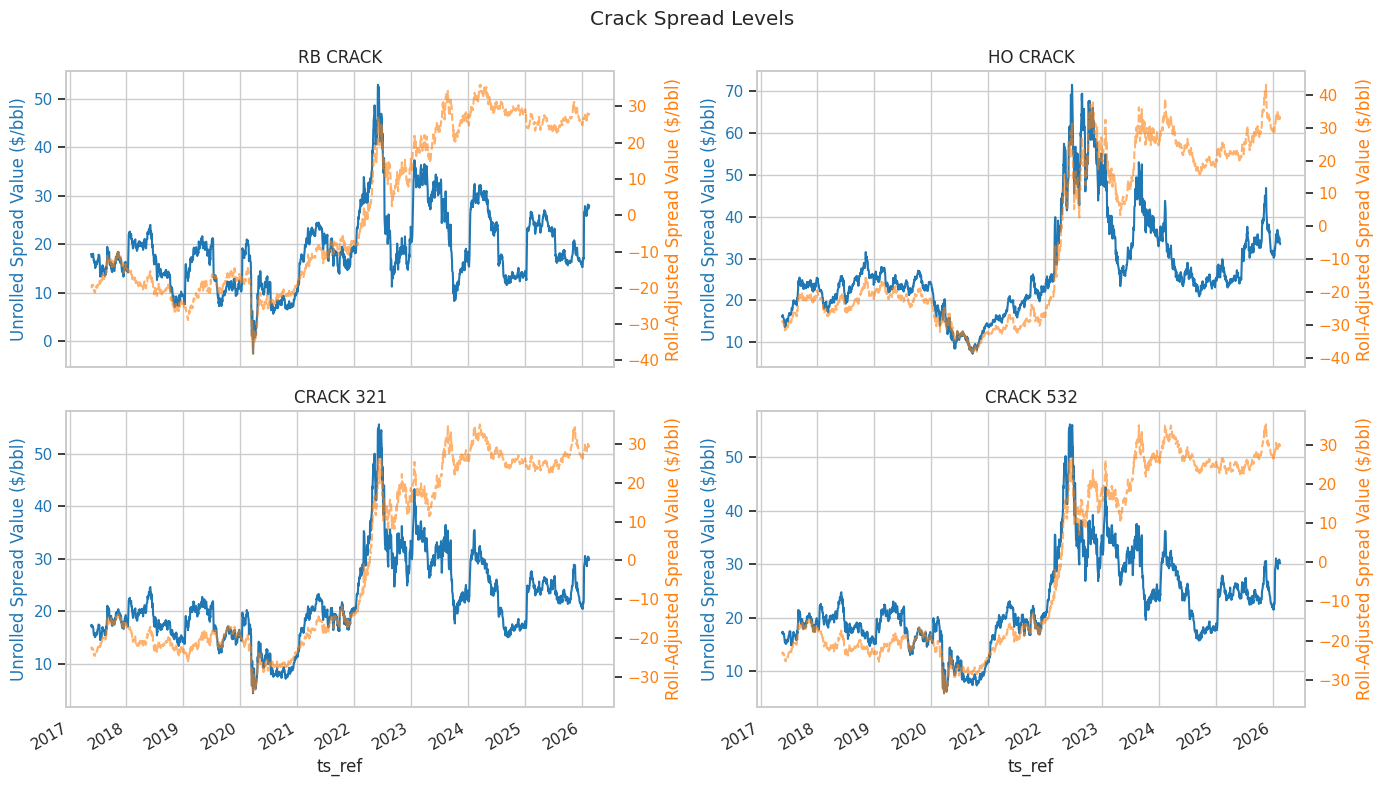

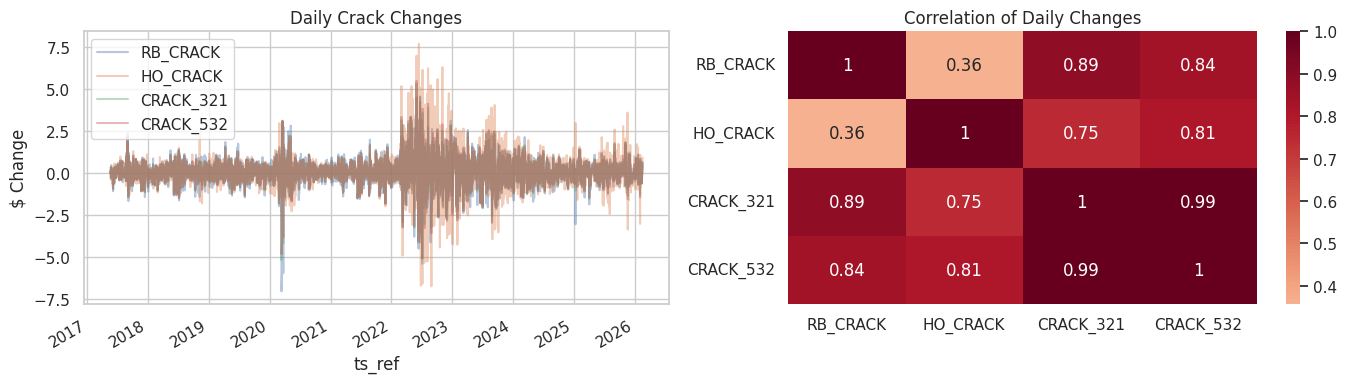


Daily Returns


,mean,std,min,max
RB_CRACK,0.023,0.831,-7.070,4.469
HO_CRACK,0.029,1.150,-6.774,7.673
CRACK_321,0.025,0.778,-5.215,5.300
CRACK_532,0.025,0.790,-5.092,5.466


In [4]:
level_df      = pd.DataFrame({name.upper(): marks['price'] for name, marks in spread_marks.items()}).dropna()
roll_level_df = pd.DataFrame({name.upper(): marks['price_roll_adjusted'] for name, marks in spread_marks.items()}).dropna()
change_df     = pd.DataFrame({name.upper(): marks['price_chg'] for name, marks in spread_marks.items()}).dropna()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), sharex=True)
for ax, spread_name in zip(axes.flatten(), level_df.columns):
    level_df[spread_name].plot(ax=ax, title=spread_name.replace('_', ' ').upper(), color='tab:blue', label='Unrolled')
    ax.set_ylabel('Unrolled Spread Value ($/bbl)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    roll_level_df[spread_name].reindex(level_df.index).plot(ax=ax2, ls='--', color='tab:orange', alpha=0.6, label='Roll-adjusted')
    ax2.set_ylabel('Roll-Adjusted Spread Value ($/bbl)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax2.grid(visible=False)

plt.suptitle('Crack Spread Levels')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
change_df.plot(ax=axes[0], alpha=0.4)
axes[0].set_title('Daily Crack Changes')
axes[0].set_ylabel('$ Change')

sns.heatmap(change_df.corr().round(3), annot=True, cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('Correlation of Daily Changes')

plt.tight_layout()
plt.show()

print('\n' + '=' * 20)
print('Daily Returns')
print('=' * 20)
display(change_df.describe().T[['mean', 'std', 'min', 'max']].round(3))

The unrolled RBOB crack seasonality comes through clearly in the level chart. That is consistent with the grade-rotation story. HO crack is less seasonal, which is also broadly in line with the product-spec change discussed above.

The 5-3-2 and 3-2-1 structures are almost indistinguishable  with correlation of 0.99. The 5-3-2 blend is 60/40 RBOB/HO, while the 3-2-1 is roughly 67/33. That difference is too small to justify carrying both through the rest of the notebook and we shall drop 5-3-2 from this point.

The 3-2-1 is still correlated with the single-product cracks, but is different enough to be worth testing separately.

## 6.1 ACF/PACF Plots on Monthly Returns

The monthly ACF and PACF are a quick way to check whether any obvious seasonal or autoregressive structure shows up in crack changes. I use monthly changes here because the seasonal question is naturally annual, not daily.

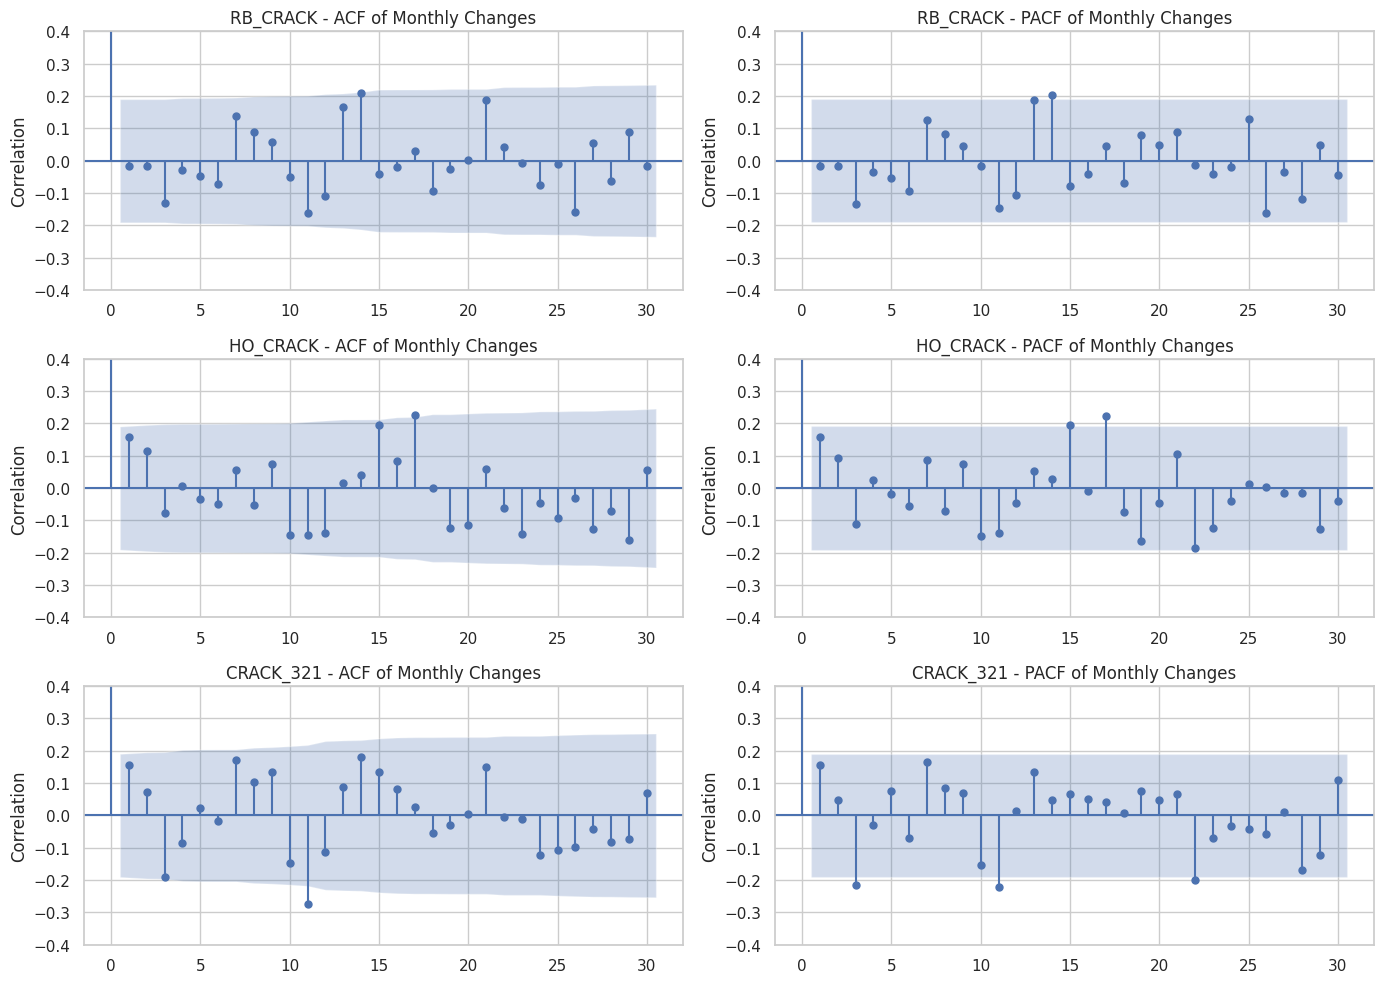

In [5]:
acf_columns = ['RB_CRACK', 'HO_CRACK', 'CRACK_321']
fig, axes   = plt.subplots(nrows=len(acf_columns), ncols=2, figsize=(14, 10))

for row_idx, column in enumerate(acf_columns):
    
    series = change_df[column].dropna().groupby(pd.Grouper(freq='ME')).sum()
    plot_acf(series, lags=30, ax=axes[row_idx, 0], title=f'{column} - ACF of Monthly Changes')
    plot_pacf(series, lags=30, ax=axes[row_idx, 1], title=f'{column} - PACF of Monthly Changes', method='ywm')
    
    axes[row_idx, 0].set_ylabel('Correlation')
    axes[row_idx, 1].set_ylabel('Correlation')

    axes[row_idx, 0].set_ylim([-0.4, 0.4])
    axes[row_idx, 1].set_ylim([-0.4, 0.4])

plt.tight_layout()
plt.show()

HO crack does not show a clean pattern. There are a few spikes around lag 15/17, but there doesn't seem to be any strong economic reason to attach meaning to those specific lags.

RBOB crack has some lag 13/14 movement, but the chart does not give a clean enough return-process story.

The 3-2-1 chart looks more interesting at first glance. The spikes around lag 11 and 22 could be read as a rough annual pattern. Let's follow up with some checks in the next section.

## 6.2 Seasonality in 3-2-1 Crack Spread

We use two cleaner checks to study the potential annual or near-annual pattern here:

1) Calendar-month average changes -- to see if there is a month-of-year effect.
2) A direct lag-12 relationship, to test whether the current month's change is related to the same month last year.

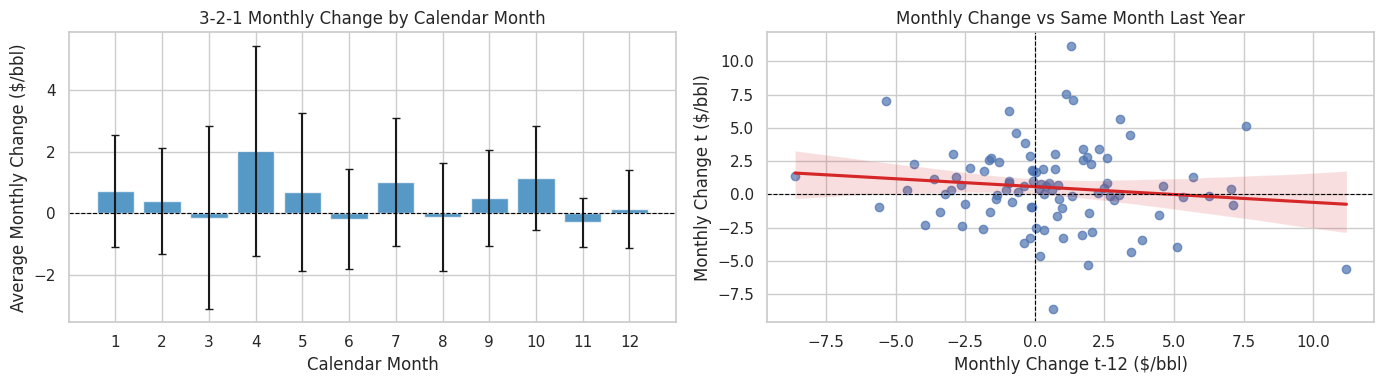

Calendar-month summary:


,mean,std,count,min,max,standard_error,ci_95
month,,,,,,,
1,0.733,2.783,9,-2.598,4.456,0.928,1.818
2,0.411,2.630,9,-4.320,3.447,0.877,1.719
3,-0.134,4.276,8,-8.615,7.104,1.512,2.963
4,2.039,4.911,8,-5.585,11.195,1.736,3.403
5,0.694,3.922,9,-3.959,7.580,1.307,2.562
6,-0.187,2.480,9,-4.592,4.595,0.827,1.620
7,1.021,3.169,9,-5.337,7.031,1.056,2.070
8,-0.114,2.702,9,-3.236,5.322,0.901,1.765
9,0.511,2.383,9,-3.398,3.853,0.794,1.557



Direct lag-12 relationship:


,n_obs,lag_12_corr,hac_t_stat,ols_alpha,ols_beta
0,94,-0.12,-1.385,0.589,-0.118


In [6]:
crack_321_monthly_change = spread_marks['crack_321']['price_chg'].dropna().resample('ME').sum()
crack_321_monthly_df = pd.DataFrame({'monthly_change': crack_321_monthly_change}).dropna()
crack_321_monthly_df['month'] = crack_321_monthly_df.index.month
crack_321_monthly_df['lag_12_change'] = crack_321_monthly_df['monthly_change'].shift(12)

month_stats = (
    crack_321_monthly_df
    .groupby('month')['monthly_change']
    .agg(['mean', 'std', 'count', 'min', 'max'])
)
month_stats['standard_error'] = month_stats['std'] / np.sqrt(month_stats['count'])
month_stats['ci_95'] = 1.96 * month_stats['standard_error']

lag_12_df = crack_321_monthly_df[['monthly_change', 'lag_12_change']].dropna()
lag_12_stats = compute_predictive_corr_stats(
    lag_12_df['lag_12_change'],
    lag_12_df['monthly_change'],
    method='pearson',
)
lag_12_beta = (
    lag_12_df['lag_12_change'].cov(lag_12_df['monthly_change'])
    / lag_12_df['lag_12_change'].var()
)
lag_12_alpha = lag_12_df['monthly_change'].mean() - lag_12_beta * lag_12_df['lag_12_change'].mean()
lag_12_summary = pd.DataFrame([
    {
        'n_obs': lag_12_stats['n_obs'],
        'lag_12_corr': lag_12_stats['corr'],
        'hac_t_stat': lag_12_stats['t_stat'],
        'ols_alpha': lag_12_alpha,
        'ols_beta': lag_12_beta,
    }
])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

axes[0].bar(
    month_stats.index,
    month_stats['mean'],
    yerr=month_stats['ci_95'],
    capsize=3,
    color='tab:blue',
    alpha=0.75,
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('3-2-1 Monthly Change by Calendar Month')
axes[0].set_xlabel('Calendar Month')
axes[0].set_ylabel('Average Monthly Change ($/bbl)')
axes[0].set_xticks(month_stats.index)

sns.regplot(
    data=lag_12_df,
    x='lag_12_change',
    y='monthly_change',
    ax=axes[1],
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'tab:red'},
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Monthly Change vs Same Month Last Year')
axes[1].set_xlabel('Monthly Change t-12 ($/bbl)')
axes[1].set_ylabel('Monthly Change t ($/bbl)')


plt.tight_layout()
plt.show()

print('Calendar-month summary:')
display(month_stats.round(3))

print('\nDirect lag-12 relationship:')
display(lag_12_summary.round(3))


The calendar-month summary does not show a clean deterministic seasonal pattern. Every month-of-year average has a 95% confidence interval that overlaps zero, including the larger positive April estimate. That makes it hard to argue that the monthly 3-2-1 change has a stable calendar-month return effect in this sample.

The direct lag-12 relationship is also weak. The same-month-last-year correlation is -0.120 across 94 observations, with a HAC t-statistic of -1.385 and a regression beta of -0.118. That is not strong enough to treat the earlier lag-11/22 ACF movement as evidence of a tradable annual-return pattern.

---

# 7. Signal Definition

We define four signals: trend and mean reversion, each split into stress and normal variants.

The hypothesis is that crack spreads behave differently across physical market states. When a supply shock hits, the move can persist for days or weeks. In that case, a faster trend signal may make sense. Under normal conditions, I would expect extreme crack levels to revert more often, while any broader trend should be measured over a slower window.

To keep the setup simple, I use two anchor horizons:

1. Short term: 40 trading days
2. Long term: 120 trading days

The trend signals are scaled by a lagged 40-day EWMA volatility estimate. For both signal families, the stress variants use the faster trend window and slower mean-reversion window. The normal variants reverse that choice.

These parameters are not optimised. They are based on market intuition and we'll later check these through sensitivity analysis.

## 7.1 Trend Signals

Both trend variants use the same form on the rolled crack series:

$$
S^{trend}_t = \frac{P^{roll}_{t-s} - P^{roll}_{t-l}}{\sigma_{rolling}}
$$

where:

1. $P^{roll}$ is the rolled crack-spread price
2. $l$ is the lookback window
3. $s$ is the skip window
4. $\sigma\_{rolling}$ is the lagged 40-day EWMA standard deviation of crack changes

The sign convention is straightforward. If the recent rolled price is above the older rolled price, the trend signal is positive. A positive signal maps to a long crack position in the backtest.

I include a skip window because very short-term reversals can contaminate the trend signal. Under stressed conditions, I use a 40-day lookback with a 2-day skip. Under normal conditions, I use a 120-day lookback with a 5-day skip.

## 7.2 Mean-Reversion (or Roll) Signals

Both mean-reversion variants use a percentile-rank form on the unrolled crack series:

$$
S^{mr}_t = -2 \times (Rank_t(L) - 0.5)
$$

where $Rank\_t(L)$ is the percentile rank of the current crack level within the trailing $L$ observations.

The negative sign means high crack levels produce short signals and low crack levels produce long signals. The signal here is not scaled as percentile ranking is already bounded and  is already unitless. An alternative interpretation to this signal is `roll`, where futures roll up/down depending on the term structure.

I use percentile ranking rather than moving-average crossover because crack spreads are more naturally read relative to their own \`nearby\` history. Under stressed conditions, the rank is computed over 120 days so the signal only reacts to broader extremes. Whereas under normal conditions, the rank window is 40 days so the signal reacts to local range extension.

## 7.3 Parameter Summary

| Signal         | Regime | Source series | Primary window           | Skip   | Volatility lookback |
| -------------- | ------ | ------------- | ------------------------ | ------ | ------------------- |
| Trend          | Stress | Rolled        | Lookback = 40 days       | 2 days | EWMA span = 40 days |
| Trend          | Normal | Rolled        | Lookback = 120 days      | 5 days | EWMA span = 40 days |
| Mean reversion | Stress | Unrolled      | Rank lookback = 120 days | N/A    | N/A                 |
| Mean reversion | Normal | Unrolled      | Rank lookback = 40 days  | N/A    | N/A                 |

In [7]:
def signal_trend(
    spread_roll_adjusted: pd.Series,
    lookback: int,
    skip: int,
    vol_lookback: int,
) -> pd.Series:
    """Compute a trend signal on the rolled spread series."""
    clean      = spread_roll_adjusted.dropna().astype(float)
    trend_move = clean.shift(skip) - clean.shift(lookback)
    scale      = clean.diff().ewm(span=vol_lookback, adjust=False, min_periods=vol_lookback).std().shift(1)
    signal     = (trend_move / scale).rename('trend')
    return signal.reindex(spread_roll_adjusted.index)


def signal_mean_reversion(
    spread_price: pd.Series,
    rank_lookback: int,
    vol_lookback: int | None = None,
) -> pd.Series:
    """Compute rank-native mean reversion on the unrolled spread series."""
    percentile_rank = rolling_percentile_rank(spread_price, window=rank_lookback)
    centered_rank   = percentile_rank - 0.5
    signal          = (-2.0 * centered_rank).rename('mean_reversion')
    return signal.reindex(spread_price.index)


In [8]:
HORIZON_DAYS                  = 2
IC_HORIZONS                   = range(1, 6)
CUMULATIVE_IC_HORIZONS        = range(2, 6)
TERM_STRUCTURE_FLAT_THRESHOLD = 0.10
ONE_WAY_COST_PER_CONTRACT     = 0.03 # Simple one-way research cost assumption for this showcase.
PERIODS_PER_YEAR              = 252

SIGNAL_CONFIGS = {
    'stress_trend' : {
        'family' : 'trend', 'regime': 'stress', 'source': 'rolled', 'lookback': 40, 'skip': 2,'vol_lookback': 40},

    'stress_mean_reversion' : {
        'family' : 'mean_reversion', 'regime': 'stress', 'source': 'unrolled', 'rank_lookback': 120, 'vol_lookback': 40},

    'normal_trend' : {
        'family' : 'trend', 'regime': 'normal', 'source': 'rolled', 'lookback': 120, 'skip': 5, 'vol_lookback': 40},

    'normal_mean_reversion' : {
        'family' : 'mean_reversion', 'regime': 'normal', 'source': 'unrolled', 'rank_lookback': 40, 'vol_lookback': 40},
}

SIGNAL_ORDER  = list(SIGNAL_CONFIGS.keys())

STRESS_SIGNALS = [name for name, cfg in SIGNAL_CONFIGS.items() if cfg['regime'] == 'stress']
NORMAL_SIGNALS = [name for name, cfg in SIGNAL_CONFIGS.items() if cfg['regime'] == 'normal']

SUMMER_MONTHS  = {4, 5, 6, 7, 8, 9}

ACTIVE_SPREADS = ['rb_crack', 'ho_crack', 'crack_321']
active_spread_marks = {name: spread_marks[name] for name in ACTIVE_SPREADS}
active_spread_marks_is = {
    name: slice_frame(marks, IS_START, IS_END)
    for name, marks in active_spread_marks.items()
}
signal_functions = {
    'trend': signal_trend,
    'mean_reversion': signal_mean_reversion,
}

backtest_frames = {
    spread_name: prepare_backtest_frame(
        marks                         = marks,
        cl_front                      = cl_nb1,
        cl_second                     = cl_nb2,
        signal_configs                = SIGNAL_CONFIGS,
        signal_order                  = SIGNAL_ORDER,
        signal_functions              = signal_functions,
        horizon_days                  = HORIZON_DAYS,
        term_structure_flat_threshold = TERM_STRUCTURE_FLAT_THRESHOLD,
        one_way_cost_per_contract     = ONE_WAY_COST_PER_CONTRACT,
        summer_months                 = SUMMER_MONTHS,
    )
    for spread_name, marks in active_spread_marks.items()
}

backtest_frames_is = {
    name: slice_frame(frame, IS_START, IS_END)
    for name, frame in backtest_frames.items()
}
backtest_frames_oos = {
    name: slice_frame(frame, OOS_START, OOS_END)
    for name, frame in backtest_frames.items()
}

# From this point through the portfolio construction section, diagnostics use
# the IS slice. The full sample is only reused for descriptive charts or the
# explicit OOS/event checks later.
research_frames = backtest_frames_is

pd.DataFrame({
    spread_name: frame[SIGNAL_ORDER].count()
    for spread_name, frame in research_frames.items()
}).T


,stress_trend,stress_mean_reversion,normal_trend,normal_mean_reversion
rb_crack,989,989,989,989
ho_crack,989,989,989,989
crack_321,989,989,989,989


---

# 8.  Information Coefficients (In-Sample)

Before backtesting, let us first check if the signals have any directional relationship with subsequent crack moves.

The alignment here is important. We cannot produce and consume the signal exactly at the same time. If we had more granular data, we could assume that we enter our positions after a short delay from the time the settlement data gets released by hitting/lifting at BBO. As our signals here are assumed to be produced at time $T$ and our data here happened to be daily settlement, the earliest timestamp we could enter a position is at time $T+1$. The main target here is therefore `terminal_change_2d`, which refers to the realised return from $T+1$ to $T+2$.

Alternatively, with daily settlement data only, we could assume that we trade at settlement price (that produced the signal) and add in some slippage cost assumption, which would work as well, provided it is reasonable.

We'll study both the terminal IC and cumulative IC, which answers if the signal predicts price move on a specific future day and if the signal predicts the total move over a forward window. We use Newey-West corrected t-statistics due to the serially dependent signals and residuals. For cumulative IC, the overlap is an additional reason to prefer HAC inference.

As a rough heuristic, we should treat an IC as having potential if it is positive (>= 0.03) with t-statistics consistently around 1.5-2.0 or higher.

We print an averaged IC/t-stat table. The values in the table are descriptive summaries and the averaged t-stat should not be interpreted as a formal pooled test statistic.

,spread,signal_label,horizon,terminal_ic,terminal_t_stat,n_obs
0,rb_crack,Stress trend,1,-0.044565,-1.405425,988
1,rb_crack,Stress trend,2,-0.046156,-1.479610,987
2,rb_crack,Stress trend,3,-0.034593,-1.107387,986
3,rb_crack,Stress trend,4,-0.043289,-1.347302,985
4,rb_crack,Stress trend,5,-0.031010,-0.984866,984


,spread,signal_label,horizon,cumulative_ic,cumulative_t_stat,n_obs
0,rb_crack,Stress trend,2,-0.065777,-1.585455,987
1,rb_crack,Stress trend,3,-0.071760,-1.405786,986
2,rb_crack,Stress trend,4,-0.071055,-1.236183,985
3,rb_crack,Stress trend,5,-0.071695,-1.138491,984
4,rb_crack,Stress mean reversion,2,0.028047,0.679869,987


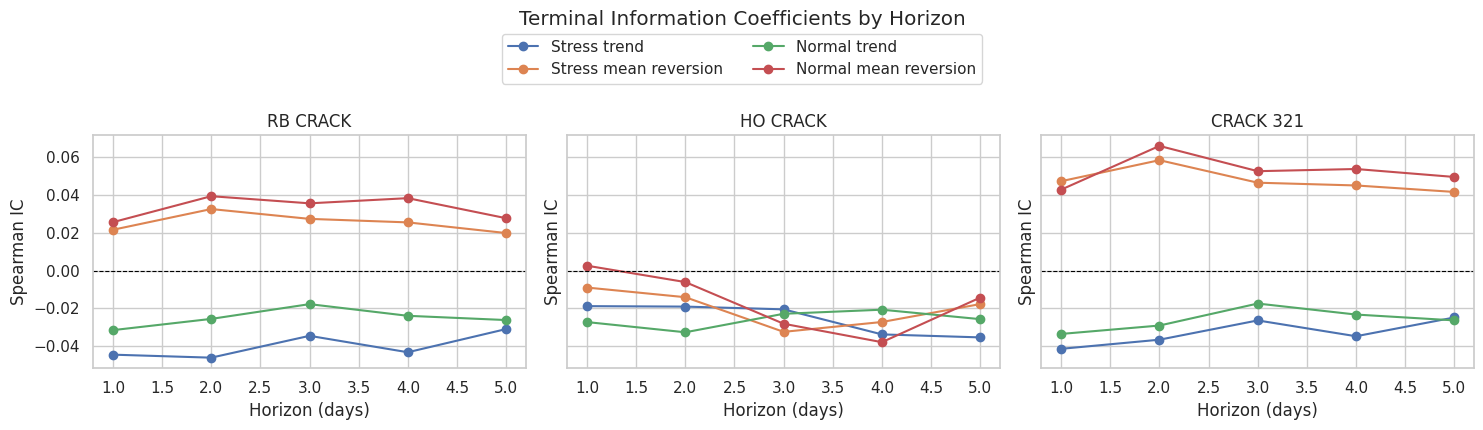

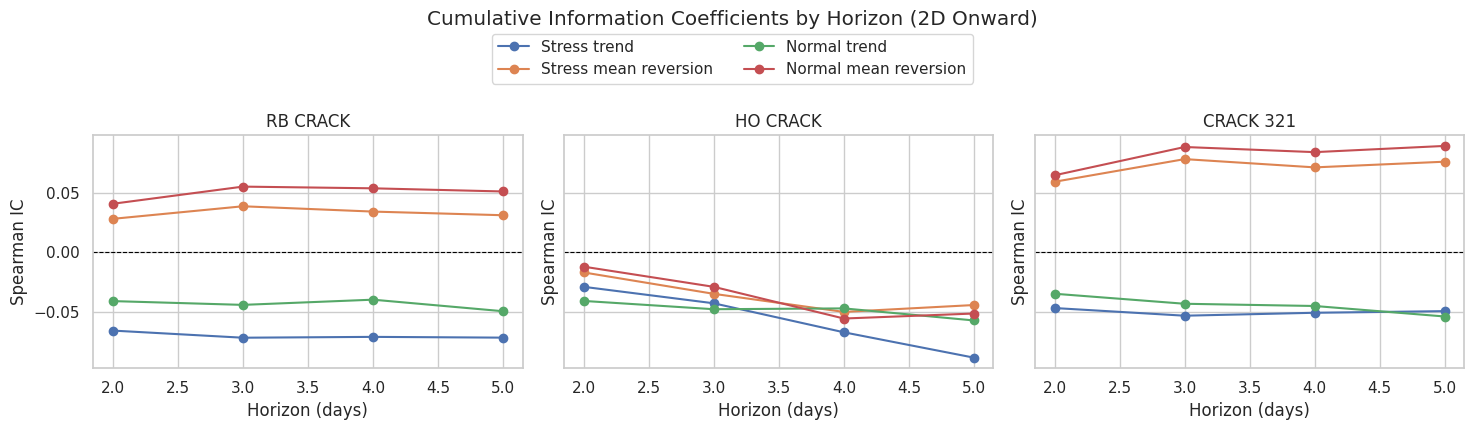


Summary


terminal_ic  terminal_t_stat cumulative_ic  \
signal_label          horizon                                               
Normal mean reversion 1              0.024            0.815             -   
                      2              0.033            1.096         0.031   
                      3              0.020            0.672         0.038   
                      4              0.018            0.642         0.027   
                      5              0.021            0.707          0.03   
Normal trend          1             -0.031           -1.014             -   
                      2             -0.029           -0.946        -0.039   
                      3             -0.019           -0.628        -0.045   
                      4             -0.023           -0.746        -0.044   
                      5             -0.026           -0.870        -0.054   
Stress mean reversion 1              0.020            0.638             -   
                      2              0.026            0.791         0.023   
                      3              0.014            0.413         0.027   
                      4              0.014            0.444         0.018   
                      5              0.015            0.451         0.021   
Stress trend          1             -0.035           -1.118             -   
                      2             -0.034           -1.102        -0.047   
                      3             -0.027           -0.887        -0.056   
                      4             -0.037           -1.193        -0.063   
                      5             -0.030           -0.985         -0.07   

                              cumulative_t_stat  
signal_label          horizon                    
Normal mean reversion 1                       -  
                      2                   0.784  
                      3                   0.827  
                      4                   0.525  
                      5                   0.507  
Normal trend          1                       -  
                      2                  -0.948  
                      3                    -0.9  
                      4                  -0.771  
                      5                   -0.86  
Stress mean reversion 1                       -  
                      2                   0.577  
                      3                    0.55  
                      4                   0.336  
                      5                    0.34  
Stress trend          1                       -  
                      2                  -1.146  
                      3                  -1.107  
                      4                  -1.087  
                      5                  -1.104

In [9]:
terminal_ic_rows   = []
cumulative_ic_rows = []

for spread_name, frame in research_frames.items():
    for signal_name in SIGNAL_ORDER:
        
        for horizon in IC_HORIZONS:
            terminal_change = compute_terminal_change(frame['price_chg'], horizon)
            terminal_stats  = compute_predictive_corr_stats(frame[signal_name], terminal_change, method='spearman')
            
            terminal_ic_rows.append({
                'spread'            : spread_name,
                'signal'            : signal_name,
                'signal_label'      : signal_label(signal_name),
                'regime_bucket'     : SIGNAL_CONFIGS[signal_name]['regime'],
                'horizon'           : horizon,
                'terminal_ic'       : terminal_stats['corr'],
                'terminal_t_stat'   : terminal_stats['t_stat'],
                'n_obs'             : terminal_stats['n_obs'],
            })
            
        for horizon in CUMULATIVE_IC_HORIZONS:
            forward_change = compute_forward_change(frame['price_chg'], horizon)
            forward_stats  = compute_predictive_corr_stats(frame[signal_name], forward_change, method='spearman')
            
            cumulative_ic_rows.append({
                'spread'            : spread_name,
                'signal'            : signal_name,
                'signal_label'      : signal_label(signal_name),
                'regime_bucket'     : SIGNAL_CONFIGS[signal_name]['regime'],
                'horizon'           : horizon,
                'cumulative_ic'     : forward_stats['corr'],
                'cumulative_t_stat' : forward_stats['t_stat'],
                'n_obs'             : forward_stats['n_obs'],
            })

terminal_ic_df   = pd.DataFrame(terminal_ic_rows)
cumulative_ic_df = pd.DataFrame(cumulative_ic_rows)

display(terminal_ic_df[['spread', 'signal_label', 'horizon', 'terminal_ic', 'terminal_t_stat', 'n_obs']].head())
display(cumulative_ic_df[['spread', 'signal_label', 'horizon', 'cumulative_ic', 'cumulative_t_stat', 'n_obs']].head())


fig, axes = plt.subplots(nrows=1, ncols=len(research_frames), figsize=(5 * len(research_frames), 4), sharex=True, sharey=True)
axes      = np.atleast_1d(axes)

for ax, spread_name in zip(axes.flatten(), research_frames.keys()):
    
    subset = terminal_ic_df[terminal_ic_df['spread'] == spread_name]
    
    for signal_name in SIGNAL_ORDER:
        
        signal_subset = subset[subset['signal'] == signal_name]
        
        ax.plot(
            signal_subset['horizon'],
            signal_subset['terminal_ic'],
            marker = 'o',
            label  = signal_label(signal_name),
        )
        
    ax.set_title(spread_name.replace('_', ' ').upper())
    ax.set_xlabel('Horizon (days)')
    ax.set_ylabel('Spearman IC')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.03))
plt.suptitle('Terminal Information Coefficients by Horizon', y=1.07)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=len(research_frames), figsize=(5 * len(research_frames), 4), sharex=True, sharey=True)
axes      = np.atleast_1d(axes)

for ax, spread_name in zip(axes.flatten(), research_frames.keys()):
    subset = cumulative_ic_df[cumulative_ic_df['spread'] == spread_name]
    
    for signal_name in SIGNAL_ORDER:
        signal_subset = subset[subset['signal'] == signal_name]
        ax.plot(
            signal_subset['horizon'],
            signal_subset['cumulative_ic'],
            marker = 'o',
            label  = signal_label(signal_name),
        )
        
    ax.set_title(spread_name.replace('_', ' ').upper())
    ax.set_xlabel('Horizon (days)')
    ax.set_ylabel('Spearman IC')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.03))
plt.suptitle('Cumulative Information Coefficients by Horizon (2D Onward)', y=1.07)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

terminal_ic_summary_df = (
    terminal_ic_df.groupby(['signal_label', 'horizon'])[['terminal_ic', 'terminal_t_stat']]
    .mean()
    .round(3)
)
cumulative_ic_summary_df = (
    cumulative_ic_df.groupby(['signal_label', 'horizon'])[['cumulative_ic', 'cumulative_t_stat']]
    .mean()
    .round(3)
)

print('\n' + '=' * 20)
print('Summary')
print('=' * 20)
display(pd.concat([terminal_ic_summary_df, cumulative_ic_summary_df], axis=1).fillna('-'))

The in-sample IC picture is weak. Most values are small, and the t-statistics are not strong enough to make a confident directional claim. (I left the printing of tables out, but results are generally weak. Feel free to re-run this notebook locally.)

Across the three product cracks, the broad pattern is that the mean-reversion signals are mostly positive, while the trend variants are generally negative. The magnitudes are still small, so I would not treat this as  evidence of a tradable mean-reversion effect. However, it does suggest that the simple trend-following story is not well supported unconditionally.

The mean-reversion result looks more constructive for RBOB and 3-2-1, especially beyond the single-day horizon. That makes some sense because 3-2-1 still contains a large gasoline-crack component, so it should not be surprising if it shares some behaviour with RBOB.  The ICs are not strong enough by themselves, but they do tell us where the signal family is more aligned with the original hypothesis.

On the other hand, HO crack looks partly flipped relative to RBOB and 3-2-1.

As the point of this notebook is to showcase my research methodologies, despite the weak IC, we shall continue on and perform robustness checks and portfolio diagnostics.

## 8.1 Bootstrap IC Confidence Intervals

Point estimates do not tell the full story, especially when the estimated ICs are this small. It does not tell us how stable that estimate is and how confident we are that the estimated values are no different from the null -- i.e. In this case, 0.

Here, we build a confidence interval around the estimates by running a block bootstrap on the 2-day terminal IC (our target variable). I resample 1,000 times using 21-trading-day blocks, so the resample still keeps some of the short-run dependence in daily crack changes. The table reports the IC and its 95% bootstrapped confidence interval.

If the interval spans zero, we should not treat the IC as meaningfully different from not having any predictive relationship. Unsurprisingly, most intervals crosses zero, consistent with the earlier results.

In [10]:
bootstrap_rows = []
for spread_name, frame in research_frames.items():
    terminal_change = frame[f'terminal_change_{HORIZON_DAYS}d']
    for signal_name in SIGNAL_ORDER:
        result = bootstrap_ic_ci(
            frame[signal_name],
            terminal_change,
            n_bootstrap=1000,
            block_length=21,
            ci_level=0.95,
            method='spearman',
        )
        bootstrap_rows.append({
            'spread': spread_name,
            'signal': signal_label(signal_name),
            'ic': result['ic'],
            'ci_5pct': result['ci_lower'],
            'ci_95pct': result['ci_upper'],
            'spans_zero': 'Yes' if result['ci_lower'] < 0 < result['ci_upper'] else 'No',
            'n_obs': result['n_obs'],
        })

bootstrap_df = pd.DataFrame(bootstrap_rows).set_index(['spread', 'signal'])
display(bootstrap_df.round(4))


ic  ci_5pct  ci_95pct spans_zero  n_obs
spread    signal                                                            
rb_crack  Stress trend          -0.0456  -0.1113    0.0203        Yes    989
          Stress mean reversion  0.0317  -0.0331    0.1018        Yes    989
          Normal trend          -0.0252  -0.0858    0.0381        Yes    989
          Normal mean reversion  0.0382  -0.0165    0.1026        Yes    989
ho_crack  Stress trend          -0.0176  -0.0772    0.0325        Yes    989
          Stress mean reversion -0.0146  -0.0736    0.0422        Yes    989
          Normal trend          -0.0304  -0.0907    0.0303        Yes    989
          Normal mean reversion -0.0062  -0.0728    0.0495        Yes    989
crack_321 Stress trend          -0.0357  -0.1043    0.0266        Yes    989
          Stress mean reversion  0.0569   0.0035    0.1204         No    989
          Normal trend          -0.0281  -0.0875    0.0311        Yes    989
          Normal mean reversion  0.0640   0.0131    0.1267         No    989

## 8.2 Rolling Information Coefficients

A full (in-) sample IC can hide where the signals may/may not have actually worked. We plot rolling ICs to see whether the relationship is broad-based or concentrated in one market.

Using a 126-day rolling window, roughly six months, makes this easier to see. Mean reversion appears to work better in some windows, but it is not consistently positive across the full sample. The trend variants also spend a fair amount of time below zero, which are all consistent with the earlier full-sample IC results. This suggests that any signal effect could be regime-dependent or event-dependent, not a smooth relationship that holds throughout the sample.

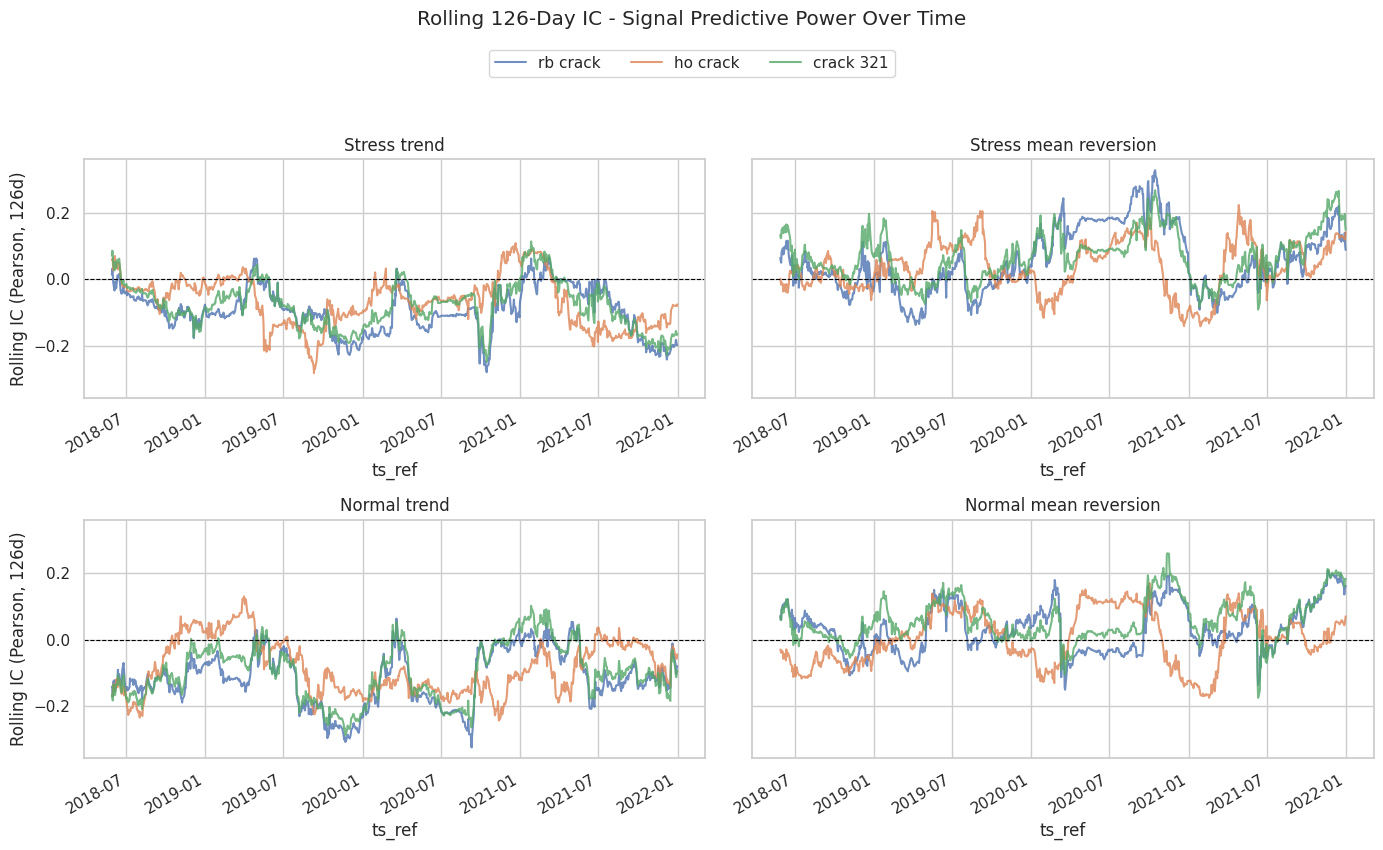

In [11]:
ROLLING_IC_WINDOW = 126

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), sharey=True)
for ax, signal_name in zip(axes.flatten(), SIGNAL_ORDER):
    for spread_name, frame in research_frames.items():
        terminal_change = frame[f'terminal_change_{HORIZON_DAYS}d']
        aligned = pd.concat([
            frame[signal_name].rename('sig'),
            terminal_change.rename('fwd'),
        ], axis=1).dropna()
        # Rolling Pearson as a fast approximation of rolling Spearman IC
        rolling_ic = aligned['sig'].rolling(ROLLING_IC_WINDOW).corr(aligned['fwd'])
        rolling_ic.plot(ax=ax, label=spread_name.replace('_', ' '), alpha=0.8)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(signal_label(signal_name))
    ax.set_ylabel(f'Rolling IC (Pearson, {ROLLING_IC_WINDOW}d)')

handles, labels_list = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_list, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))
plt.suptitle(f'Rolling {ROLLING_IC_WINDOW}-Day IC - Signal Predictive Power Over Time', y=1.06)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## 8.3 Sensitivity Analysis

We perform a narrow parameter sweep around the chosen parameters (lookback windows and skip days) to identify if the results depends too much on one specific window.

An IC that flips signs with a small tweak in parameter is probably not robust in the first place. However, if the magnitude and sign holds across a small neighborhood around the chosen parameters, we can treat the chosen parameters as stable and that it is not just a lucky set of parameters to test well.

Each signal has been tested over a small grid, then aggregated to produce the heatmap below:

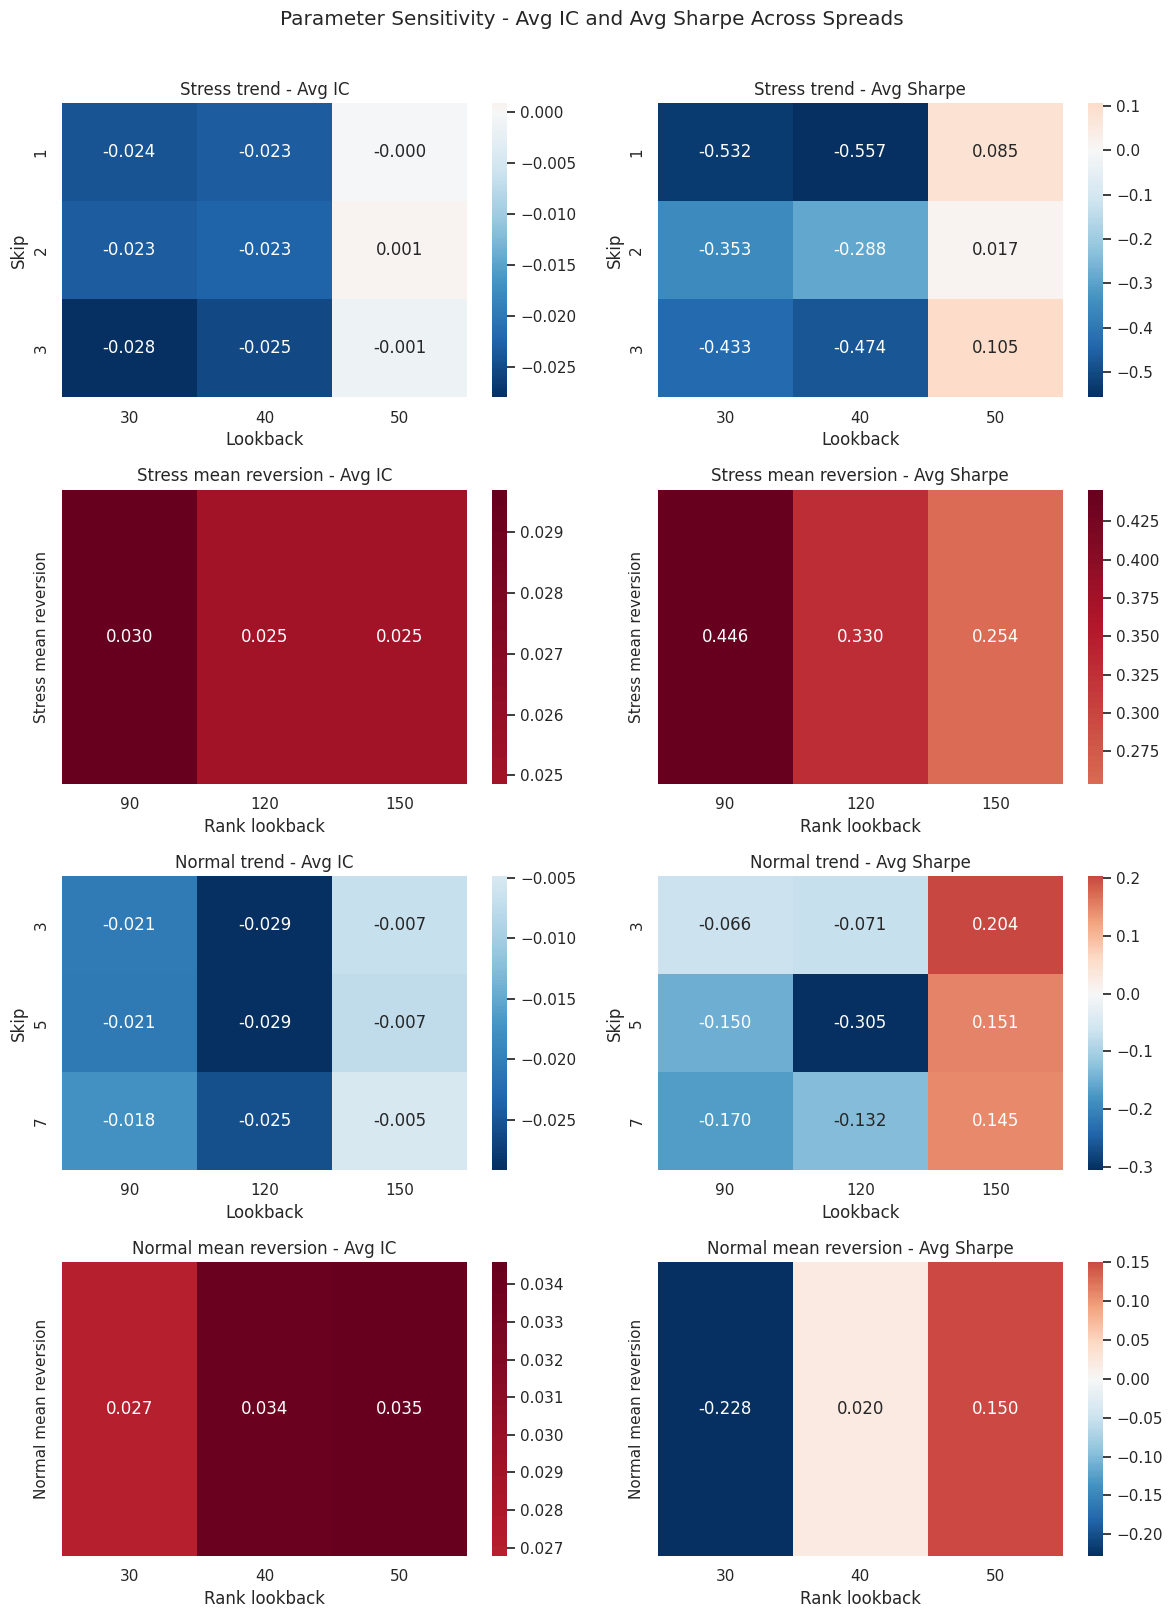

In [12]:
sensitivity_grids = {
    'stress_trend': [{'x': x, 'y': y} for x in [30, 40, 50] for y in [1, 2, 3] if y < x],
    'stress_mean_reversion': [{'x': x, 'y': 0} for x in [90, 120, 150]],
    'normal_trend': [{'x': x, 'y': y} for x in [90, 120, 150] for y in [3, 5, 7] if y < x],
    'normal_mean_reversion': [{'x': x, 'y': 0} for x in [30, 40, 50]],
}

sensitivity_results = {
    signal_name: evaluate_signal_grid(
        signal_name,
        parameter_grid,
        spread_marks=active_spread_marks_is,
        signal_configs=SIGNAL_CONFIGS,
        signal_functions=signal_functions,
        horizon_days=HORIZON_DAYS,
        one_way_cost_per_contract=ONE_WAY_COST_PER_CONTRACT,
        periods_per_year=PERIODS_PER_YEAR,
    )
    for signal_name, parameter_grid in sensitivity_grids.items()
}

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
for row_idx, signal_name in enumerate(SIGNAL_ORDER):
    result = sensitivity_results[signal_name]
    if SIGNAL_CONFIGS[signal_name]['family'] == 'trend':
        index_col, column_col = 'y', 'x'
        y_label, x_label = 'Skip', 'Lookback'
    else:
        index_col, column_col = 'signal', 'x'
        y_label, x_label = '', 'Rank lookback'
        result = result.assign(signal=signal_label(signal_name))

    ic_pivot = result.pivot(index=index_col, columns=column_col, values='avg_ic')
    sharpe_pivot = result.pivot(index=index_col, columns=column_col, values='avg_sharpe')
    sns.heatmap(ic_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, 0])
    sns.heatmap(sharpe_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, 1])
    axes[row_idx, 0].set_title(f'{signal_label(signal_name)} - Avg IC')
    axes[row_idx, 1].set_title(f'{signal_label(signal_name)} - Avg Sharpe')
    axes[row_idx, 0].set_xlabel(x_label)
    axes[row_idx, 1].set_xlabel(x_label)
    axes[row_idx, 0].set_ylabel(y_label)
    axes[row_idx, 1].set_ylabel(y_label)

plt.suptitle('Parameter Sensitivity - Avg IC and Avg Sharpe Across Spreads', y=1.01)
plt.tight_layout()
plt.show()


The sensitivity results looks "stable" across the parameters tested. There are parameter choices that do flip signs, but the values are generally very small. That is another evidence that shows that these signal families do not have much predictive power **in this setup**.

## 8.4 Multiple Testing Correction

A common pitfall in signal research is to test a wide range of parameters, find one specification that looks good, and then treat that result as if it were the original hypothesis. That is not a fair read and that was indeed one of the first mistakes I made when I started my career (I did not know better).

When testing multiple parameters, the likelihood of identifying a set that perform well increases with the number of parameter set used. For a signal that is pure random noise, there is a 5% chance of rejecting the null hypothesis that there is no predictive power. For 2 independent signals that is pure random noise, there is about 9.5% chance of rejecting the null hypothesis ($1 - 0.95^2$).

Therefore, it is always good practice to keep track of the full set of parameters tested. For this notebook, the sensitivity grid is the local hypothesis family. It tests 4 signals across 3 spreads with 3-9 parameter variations each. That gives 72 spread-level specification tests.

I therefore apply two multiple-testing corrections:

1. Benjamini-Hochberg (BH), which controls the false discovery rate. This is the more relevant correction here because the tests are related and the signals are generally correlated.
2. Bonferroni, which controls the family-wise error rate. This is stricter and we include it in as a reference bar.

The p-values come from the Newey-West HAC t-statistics in the sensitivity grid, treated as approximately normal.

In [13]:
mt_rows = []
for signal_name, parameter_grid in sensitivity_grids.items():
    base_config = dict(SIGNAL_CONFIGS[signal_name])
    for params in parameter_grid:
        config = dict(base_config)
        if config['family'] == 'trend':
            config['lookback'] = params['x']
            config['skip'] = params['y']
        else:
            config['rank_lookback'] = params['x']

        for spread_name, marks in active_spread_marks_is.items():
            frame = marks[['price', 'price_roll_adjusted', 'price_chg']].copy()
            signal = _build_signal_from_config(frame, config, signal_functions)
            terminal_change = compute_terminal_change(marks['price_chg'], HORIZON_DAYS)
            stats = compute_predictive_corr_stats(signal, terminal_change, method='spearman')
            mt_rows.append({
                'signal': signal_label(signal_name),
                'x': params['x'],
                'y': params.get('y', 0),
                'spread': spread_name,
                'ic': stats['corr'],
                't_stat': stats['t_stat'],
                'n_obs': stats['n_obs'],
            })

mt_df = pd.DataFrame(mt_rows).dropna(subset=['t_stat'])
mt_df['p_raw'] = mt_df['t_stat'].apply(lambda t: float(norm.sf(abs(t)) * 2))

valid_mask = mt_df['p_raw'].notna()
reject_bh, p_adj_bh, _, _ = multipletests(mt_df.loc[valid_mask, 'p_raw'], alpha=0.05, method='fdr_bh')
mt_df.loc[valid_mask, 'p_bh'] = p_adj_bh
mt_df.loc[valid_mask, 'reject_bh'] = reject_bh
mt_df['p_bonf'] = (mt_df['p_raw'] * valid_mask.sum()).clip(upper=1.0)
mt_df['reject_bonf'] = mt_df['p_bonf'] < 0.05

summary_cols = ['signal', 'spread', 'x', 'y', 'ic', 't_stat', 'p_raw', 'p_bh', 'reject_bh', 'p_bonf', 'reject_bonf']
display(mt_df[summary_cols].sort_values(['signal', 'spread', 'x']).round(4).reset_index(drop=True))

n_tests = valid_mask.sum()
n_reject_bh = int(mt_df['reject_bh'].sum())
n_reject_bonf = int(mt_df['reject_bonf'].sum())
print(f'\nTotal tests: {n_tests}  |  BH rejections: {n_reject_bh}  |  Bonferroni rejections: {n_reject_bonf}')


,signal,spread,x,y,ic,t_stat,p_raw,p_bh,reject_bh,p_bonf,reject_bonf
0,Normal mean reversion,crack_321,30,0,0.0577,2.0657,0.0389,0.7284,False,1.0,False
1,Normal mean reversion,crack_321,40,0,0.0663,2.3222,0.0202,0.7284,False,1.0,False
2,Normal mean reversion,crack_321,50,0,0.0644,2.2372,0.0253,0.7284,False,1.0,False
3,Normal mean reversion,ho_crack,30,0,-0.0136,-0.4599,0.6456,0.9840,False,1.0,False
4,Normal mean reversion,ho_crack,40,0,-0.0118,-0.3920,0.6951,0.9840,False,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...
67,Stress trend,rb_crack,40,2,-0.0359,-1.2217,0.2218,0.7997,False,1.0,False
68,Stress trend,rb_crack,40,3,-0.0326,-1.0975,0.2724,0.7997,False,1.0,False
69,Stress trend,rb_crack,50,1,0.0007,0.0255,0.9796,0.9840,False,1.0,False
70,Stress trend,rb_crack,50,2,0.0011,0.0372,0.9704,0.9840,False,1.0,False



Total tests: 72  |  BH rejections: 0  |  Bonferroni rejections: 0


Even before applying multiple-testing correction, only a small number of 3-2-1 crack mean-reversion specifications were significant. So it is unsurprising that after applying BH and Bonferroni correction, there are still no rejections (rejection = significant results).

---

# 9.  Regime Analysis (In-Sample)

I test three regime families:

1. The crack spread's own realised-volatility regime. This is the main one and the only regime used for switching later.
2. The CL NB1/NB2 curve regime. This is a broader crude-market state variable (Contango vs Backwardation)
3. A trading-date seasonal split. This checks whether summer versus winter market conditions matter.

The rolling ICs showed that signal behaviour fluctuates  across time. That naturally raises the next question: is the performance being split by market regime? In this section, we'll check whether the signals behave differently across volatility regimes, crude term-structure regimes, and seasonal conditions.

I treat the volatility split as the main candidate because it maps most directly to the stress versus normal signal design. The crude-curve and seasonal splits are descriptive diagnostics.

In [14]:
regime_tables = {
    'Crack Volatility Regimes': {
        signal_name: summarise_regime_family(signal_name, 'vol_regime', research_frames, HORIZON_DAYS)
        for signal_name in SIGNAL_ORDER
    },
    'CL Curve Regimes': {
        signal_name: summarise_regime_family(signal_name, 'crude_curve_regime', research_frames, HORIZON_DAYS)
        for signal_name in SIGNAL_ORDER
    },
    'Seasonal Condition Regimes': {
        signal_name: summarise_regime_family(signal_name, 'seasonal_condition', research_frames, HORIZON_DAYS)
        for signal_name in SIGNAL_ORDER
    },
}

## 9.1 Crack Volatility Regimes

This is the most important regime split in the notebook. My expectations is that stress signals should look better when the crack's own realised volatility is high, while normal signals should look better outside high-volatility periods.

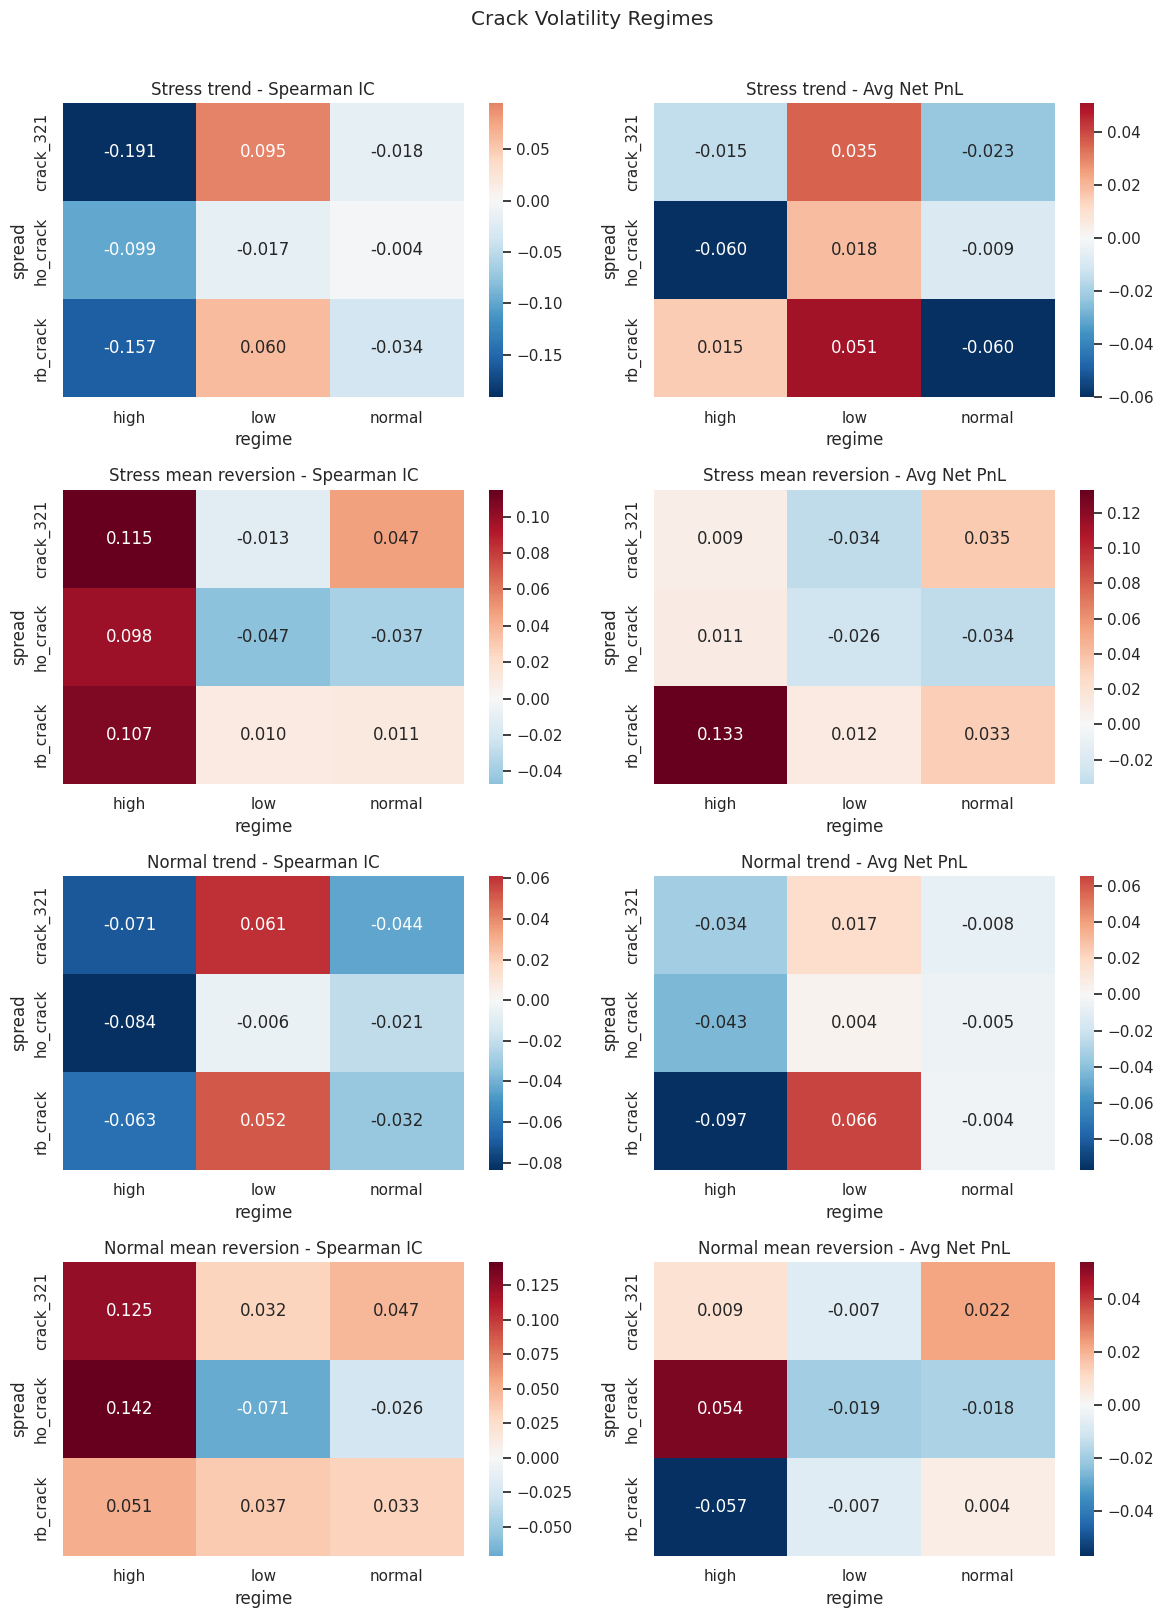

In [15]:
title  = 'Crack Volatility Regimes'
tables = regime_tables[title]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
for row_idx, signal_name in enumerate(SIGNAL_ORDER):
    summary = tables[signal_name]
    ic_pivot = summary.pivot(index='spread', columns='regime', values='spearman_ic')
    pnl_pivot = summary.pivot(index='spread', columns='regime', values='avg_net_pnl')
    sns.heatmap(ic_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, 0])
    sns.heatmap(pnl_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, 1])
    axes[row_idx, 0].set_title(f'{signal_label(signal_name)} - Spearman IC')
    axes[row_idx, 1].set_title(f'{signal_label(signal_name)} - Avg Net PnL')
plt.suptitle(title, y=1.01)
plt.tight_layout()
plt.show()

The volatility-regime result is mixed. I expected stress-trend signals to look better in high-volatility periods, but the results point more toward mean reversion. That weakens the original stress-trend hypothesis.

## 9.2 CL Curve Regimes

Backwardation, flat structure, and contango can all say something about crude inventory pressure and the wider oil complex. It would also be useful to understand if the crude term structure also helps explain product crack behavior.

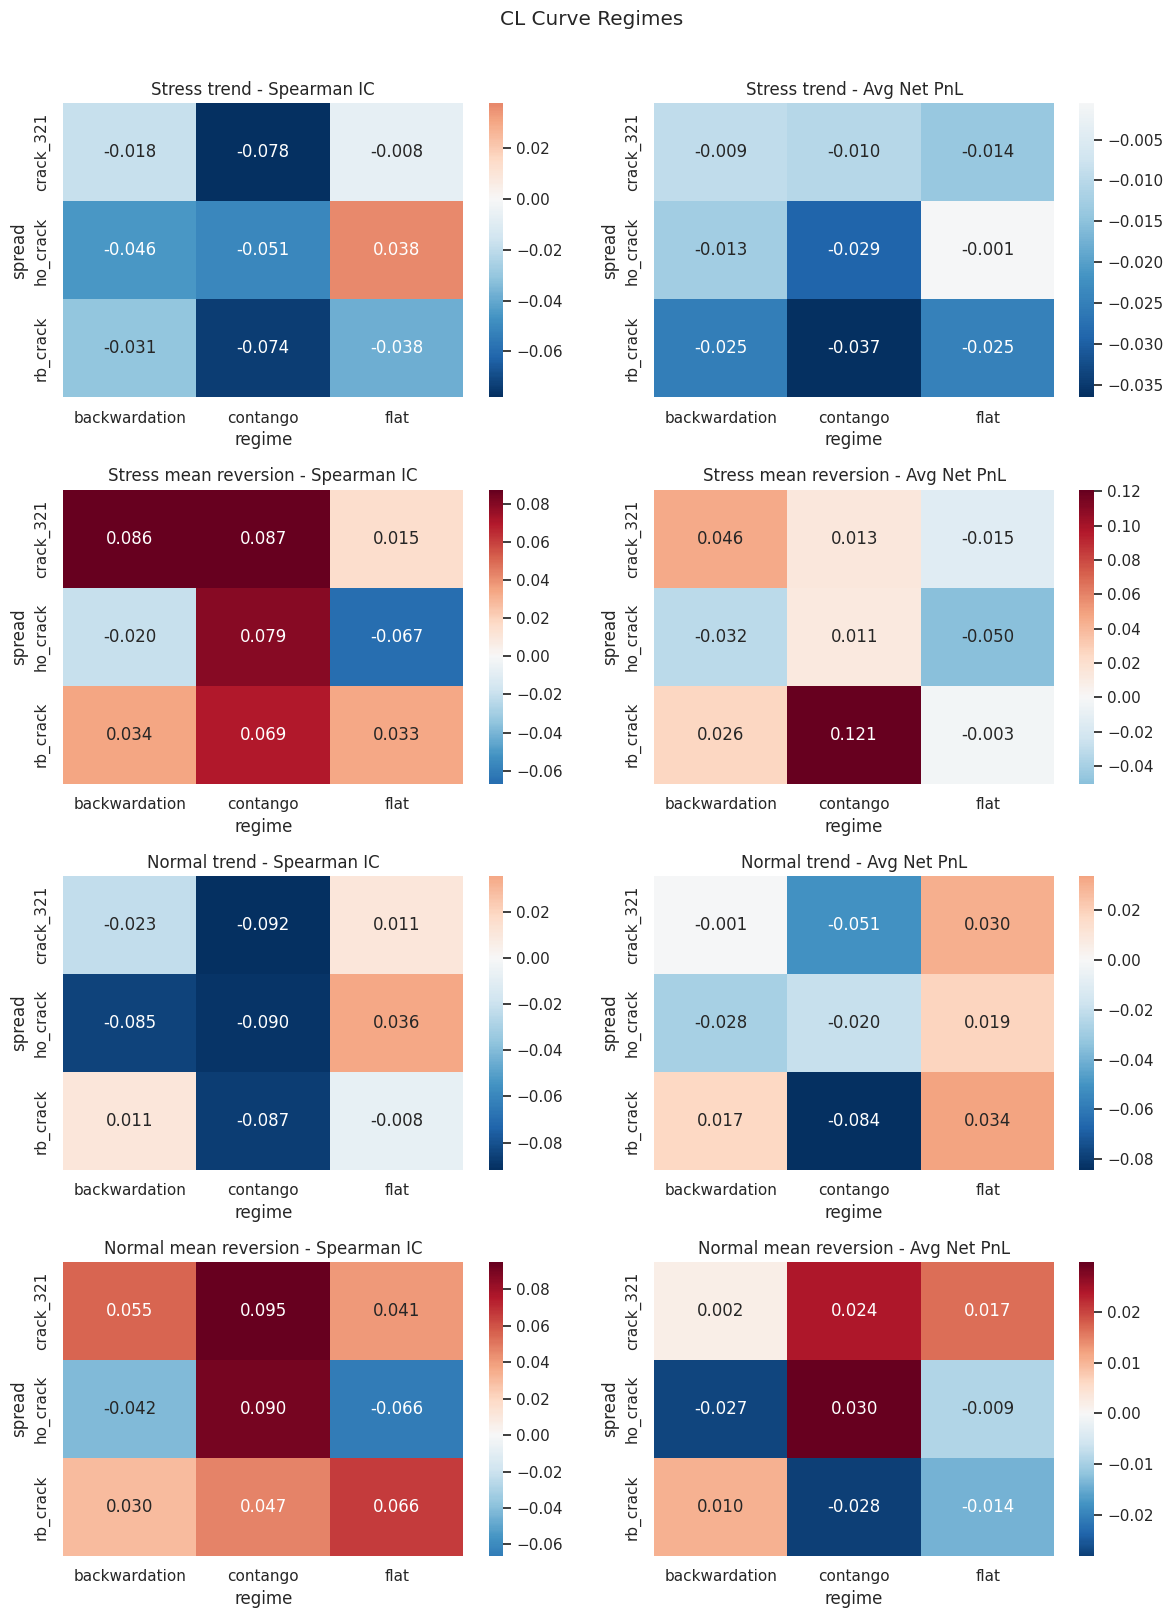

In [16]:
title  = 'CL Curve Regimes'
tables = regime_tables[title]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
for row_idx, signal_name in enumerate(SIGNAL_ORDER):
    summary = tables[signal_name]
    ic_pivot = summary.pivot(index='spread', columns='regime', values='spearman_ic')
    pnl_pivot = summary.pivot(index='spread', columns='regime', values='avg_net_pnl')
    sns.heatmap(ic_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, 0])
    sns.heatmap(pnl_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, 1])
    axes[row_idx, 0].set_title(f'{signal_label(signal_name)} - Spearman IC')
    axes[row_idx, 1].set_title(f'{signal_label(signal_name)} - Avg Net PnL')
plt.suptitle(title, y=1.01)
plt.tight_layout()
plt.show()

The crude-curve result is mixed. This just suggests the front crude curve is not the main conditioning variable for these daily crack returns.

## 9.3 Seasonal Condition Regimes

The seasonal split is motivated by product-market structure, especially gasoline's summer and winter grade switch.

For this regime study, the bucket is based on trading month, not the contract specification. If seasonality matters for the predictive relationship, I would expect at least some difference between summer and winter-season results.

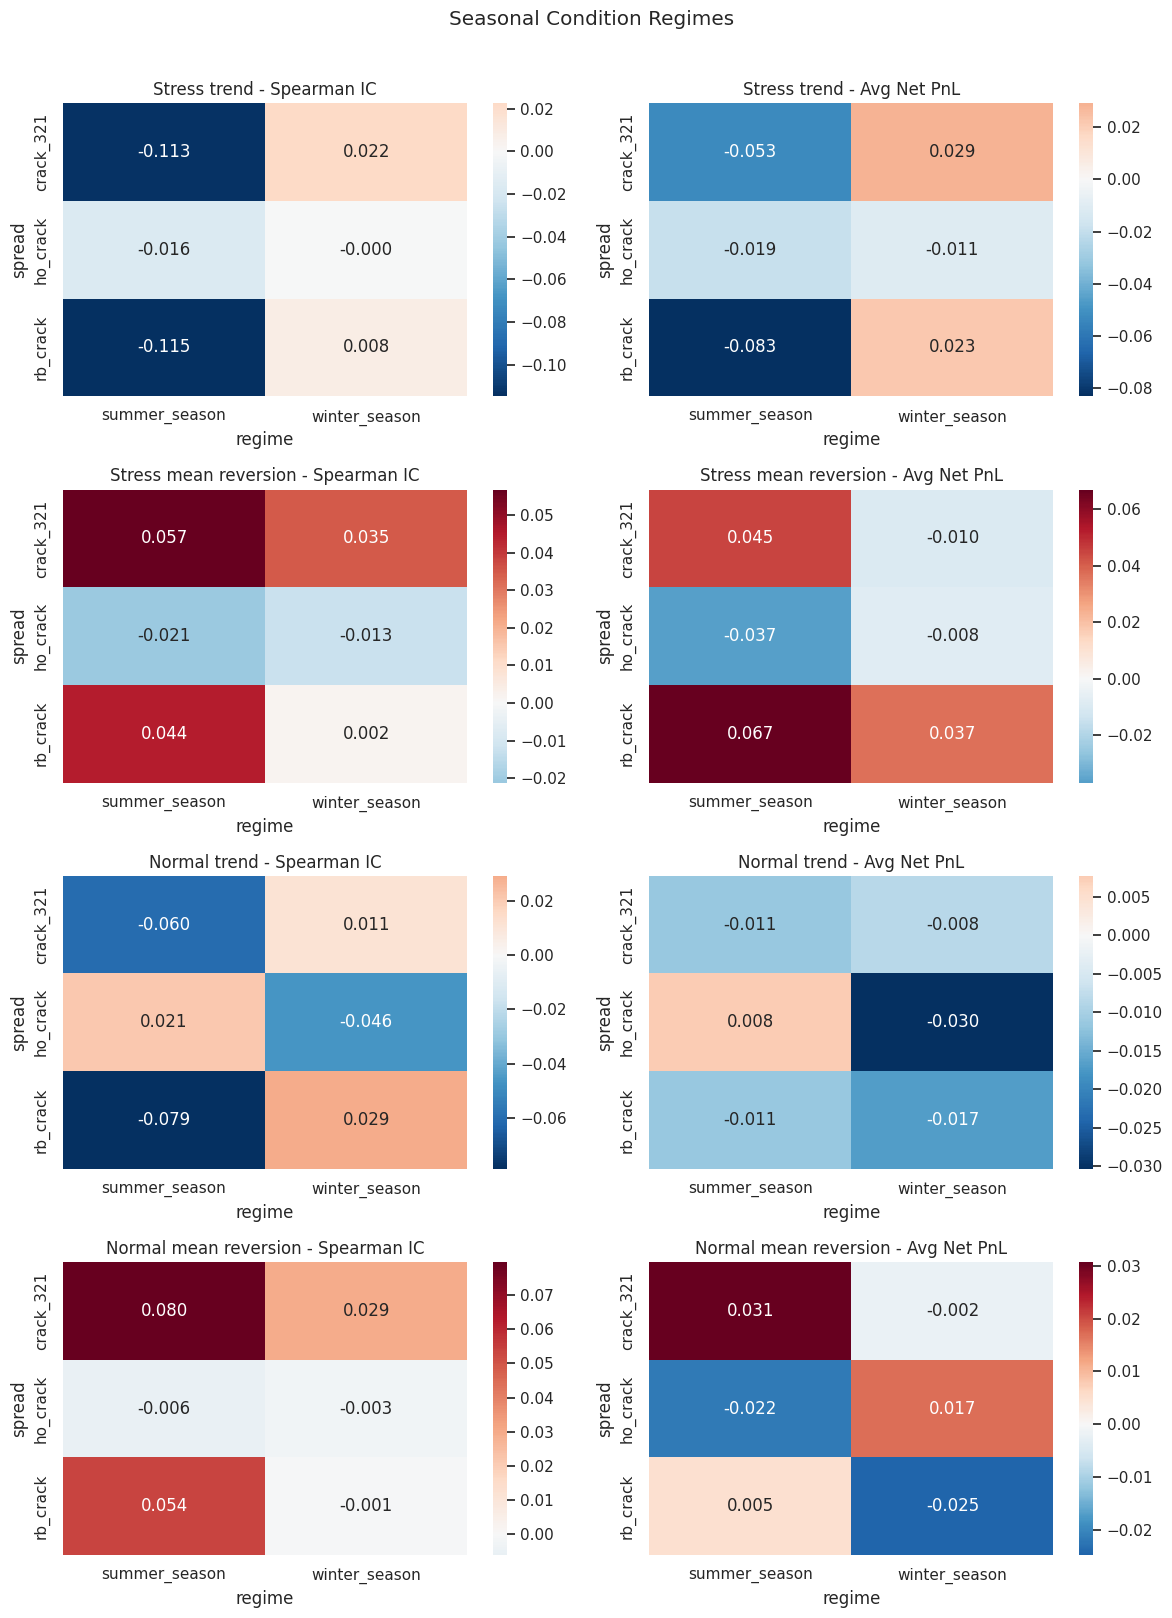

In [17]:
title  = 'Seasonal Condition Regimes'
tables = regime_tables[title]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
for row_idx, signal_name in enumerate(SIGNAL_ORDER):
    summary = tables[signal_name]
    ic_pivot = summary.pivot(index='spread', columns='regime', values='spearman_ic')
    pnl_pivot = summary.pivot(index='spread', columns='regime', values='avg_net_pnl')
    sns.heatmap(ic_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, 0])
    sns.heatmap(pnl_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[row_idx, 1])
    axes[row_idx, 0].set_title(f'{signal_label(signal_name)} - Spearman IC')
    axes[row_idx, 1].set_title(f'{signal_label(signal_name)} - Avg Net PnL')
plt.suptitle(title, y=1.01)
plt.tight_layout()
plt.show()

The seasonal result is also not clean.

## 9.4 Regime IC Delta Summary

The summary below reports regime IC, Newey-West t-statistic, and IC delta versus the full-sample baseline, averaged across the three spreads.

In [18]:
regime_delta_data = []
for regime_col, regime_label in [
    ('vol_regime', 'Vol Regime'),
    ('crude_curve_regime', 'CL Curve'),
    ('seasonal_condition', 'Seasonal Condition'),
]:
    for signal_name in SIGNAL_ORDER:
        for spread_name, frame in research_frames.items():
            terminal_change = frame[f'terminal_change_{HORIZON_DAYS}d']
            uncond_ic = compute_predictive_corr_stats(
                frame[signal_name], terminal_change, method='spearman'
            )['corr']
            for regime_val, regime_frame in frame.groupby(regime_col):
                rc = compute_predictive_corr_stats(
                    regime_frame[signal_name],
                    regime_frame[f'terminal_change_{HORIZON_DAYS}d'],
                    method='spearman',
                )
                regime_delta_data.append({
                    'regime_type': regime_label,
                    'signal': signal_label(signal_name),
                    'regime': regime_val,
                    'spread': spread_name,
                    'unconditional_ic': uncond_ic,
                    'regime_ic': rc['corr'],
                    'ic_t_stat': rc['t_stat'],
                    'n_obs': rc['n_obs'],
                    'ic_delta': rc['corr'] - uncond_ic,
                })

regime_delta_df = pd.DataFrame(regime_delta_data)
regime_delta_summary = (
    regime_delta_df.groupby(['regime_type', 'signal', 'regime'])
    [['unconditional_ic', 'regime_ic', 'ic_t_stat', 'ic_delta']]
    .mean()
    .round(3)
)
display(regime_delta_summary)

unconditional_ic  \
regime_type        signal                regime                            
CL Curve           Normal mean reversion backwardation             0.032   
                                         contango                  0.032   
                                         flat                      0.032   
                   Normal trend          backwardation            -0.028   
                                         contango                 -0.028   
                                         flat                     -0.028   
                   Stress mean reversion backwardation             0.025   
                                         contango                  0.025   
                                         flat                      0.025   
                   Stress trend          backwardation            -0.033   
                                         contango                 -0.033   
                                         flat                     -0.033   
Seasonal Condition Normal mean reversion summer_season             0.032   
                                         winter_season             0.032   
                   Normal trend          summer_season            -0.028   
                                         winter_season            -0.028   
                   Stress mean reversion summer_season             0.025   
                                         winter_season             0.025   
                   Stress trend          summer_season            -0.033   
                                         winter_season            -0.033   
Vol Regime         Normal mean reversion high                      0.032   
                                         low                       0.032   
                                         normal                    0.032   
                   Normal trend          high                     -0.028   
                                         low                      -0.028   
                                         normal                   -0.028   
                   Stress mean reversion high                      0.025   
                                         low                       0.025   
                                         normal                    0.025   
                   Stress trend          high                     -0.033   
                                         low                      -0.033   
                                         normal                   -0.033   

                                                        regime_ic  ic_t_stat  \
regime_type        signal                regime                                
CL Curve           Normal mean reversion backwardation      0.014      0.314   
                                         contango           0.077      1.524   
                                         flat               0.014      0.159   
                   Normal trend          backwardation     -0.032     -0.652   
                                         contango          -0.089     -1.813   
                                         flat               0.013      0.211   
                   Stress mean reversion backwardation      0.033      0.627   
                                         contango           0.079      1.391   
                                         flat              -0.006     -0.087   
                   Stress trend          backwardation     -0.032     -0.638   
                                         contango          -0.068     -1.272   
                                         flat              -0.003     -0.055   
Seasonal Condition Normal mean reversion summer_season      0.043      0.997   
                                         winter_season      0.009      0.220   
                   Normal trend          summer_season     -0.039     -0.914   
                                         winter_season     -0.002     -0.043   
                   Stress mean 

---

# 10. In-Sample Backtest Results

I start with standalone sign-based backtests, then move to portfolio-level constructions.

Positions are long one unit when the signal is positive and short one unit when the signal is negative.

Costs have two parts. Normal trading cost is charged when the target position changes, using a \\$0.03 per-contract one-way assumption whereas Roll cost is charged when the contract rolls, which based on our configuration, happens around the 15th or 16th of the month. I treat the roll as closing the old contract and opening the new one, so the roll-date cost is \\$0.06 per active unit.

Roll cost per active unit: $0.06


,n_rolls_full_sample,first_roll,last_roll
rb_crack,105,2017-06-15 00:00:00,2026-02-17 00:00:00
ho_crack,105,2017-06-15 00:00:00,2026-02-17 00:00:00
crack_321,105,2017-06-15 00:00:00,2026-02-17 00:00:00


signal regime_bucket  \
spread    signal_label                                                 
rb_crack  Stress trend                    stress_trend        stress   
          Stress mean reversion  stress_mean_reversion        stress   
          Normal trend                    normal_trend        normal   
          Normal mean reversion  normal_mean_reversion        normal   
ho_crack  Stress trend                    stress_trend        stress   
          Stress mean reversion  stress_mean_reversion        stress   
          Normal trend                    normal_trend        normal   
          Normal mean reversion  normal_mean_reversion        normal   
crack_321 Stress trend                    stress_trend        stress   
          Stress mean reversion  stress_mean_reversion        stress   
          Normal trend                    normal_trend        normal   
          Normal mean reversion  normal_mean_reversion        normal   

                                 mean_daily_net_pnl  annualised_net_pnl  \
spread    signal_label                                                    
rb_crack  Stress trend                       -0.032              -8.105   
          Stress mean reversion               0.048              12.216   
          Normal trend                       -0.017              -4.323   
          Normal mean reversion              -0.013              -3.323   
ho_crack  Stress trend                       -0.018              -4.575   
          Stress mean reversion              -0.025              -6.280   
          Normal trend                       -0.015              -3.696   
          Normal mean reversion              -0.005              -1.216   
crack_321 Stress trend                       -0.014              -3.547   
          Stress mean reversion               0.014               3.587   
          Normal trend                       -0.013              -3.226   
          Normal mean reversion               0.011               2.769   

                                 sharpe  sortino  hit_rate  \
spread    signal_label                                       
rb_crack  Stress trend           -0.711   -1.043     0.487   
          Stress mean reversion   1.075    1.706     0.516   
          Normal trend           -0.380   -0.500     0.496   
          Normal mean reversion  -0.291   -0.374     0.493   
ho_crack  Stress trend           -0.500   -0.682     0.494   
          Stress mean reversion  -0.687   -0.952     0.485   
          Normal trend           -0.404   -0.558     0.487   
          Normal mean reversion  -0.133   -0.189     0.492   
crack_321 Stress trend           -0.377   -0.555     0.497   
          Stress mean reversion   0.382    0.524     0.498   
          Normal trend           -0.343   -0.480     0.520   
          Normal mean reversion   0.295    0.397     0.505   

                                 avg_position_turnover  max_drawdown  \
spread    signal_label                                                 
rb_crack  Stress trend                           0.171       -33.429   
          Stress mean reversion                  0.114       -18.417   
          Normal trend                           0.054       -35.257   
          Normal mean reversion                  0.187       -34.515   
ho_crack  Stress trend                           0.151       -23.504   
          Stress mean reversion                  0.074       -31.654   
          Normal trend                           0.090       -21.388   
          Normal mean reversion                  0.116       -21.860   
crack_321 Stress trend                           0.179       -18.191   
          Stress mean reversion                  0.130       -11.967   
          Normal trend                           0.086       -26.706   
          Normal mean reversion                  0.195       -15.500   

                                 top_minus_bottom_bucket_spread  
spread    signal_label                      

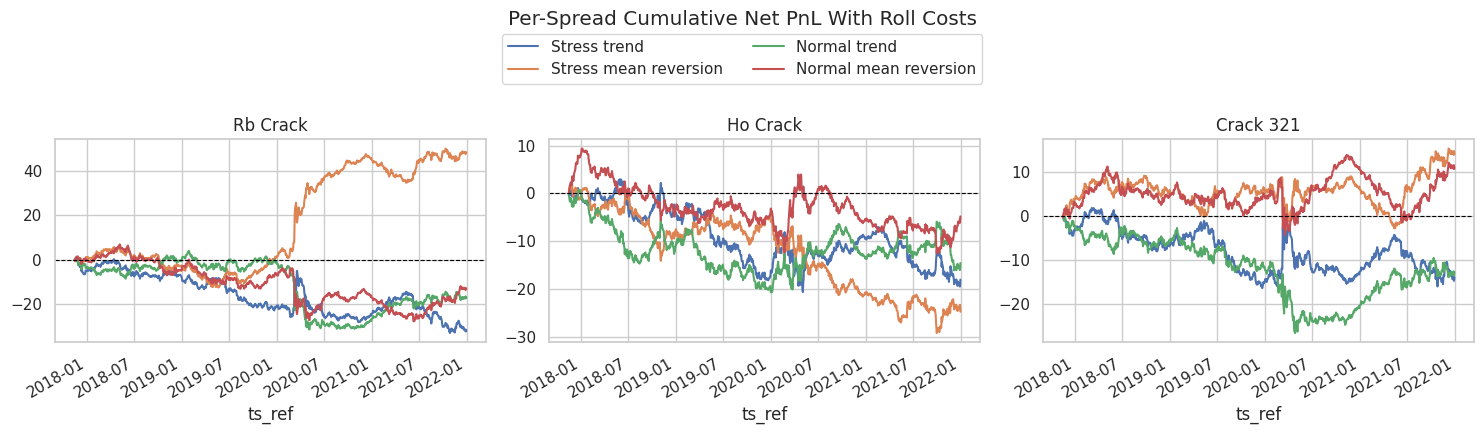

In [19]:
ROLL_COST_PER_CONTRACT = 2 * ONE_WAY_COST_PER_CONTRACT


spread_roll_flags = {
    spread_name: build_roll_flag(marks)
    for spread_name, marks in active_spread_marks.items()
}


roll_summary_df = pd.DataFrame({
    spread_name: {
        'n_rolls_full_sample': int(roll_flag.sum()),
        'first_roll': roll_flag[roll_flag].index.min(),
        'last_roll': roll_flag[roll_flag].index.max(),
    }
    for spread_name, roll_flag in spread_roll_flags.items()
}).T
print(f'Roll cost per active unit: ${ROLL_COST_PER_CONTRACT:.2f}')
display(roll_summary_df)

metric_rows   = []
top_drawdowns = {}
standalone_pnl = {}

for spread_name, frame in research_frames.items():
    for signal_name in SIGNAL_ORDER:
        pnl = compute_position_pnl_with_roll(
            frame[signal_name],
            frame[f'terminal_change_{HORIZON_DAYS}d'],
            spread_roll_flags[spread_name],
            one_way_cost=ONE_WAY_COST_PER_CONTRACT,
            roll_cost=ROLL_COST_PER_CONTRACT,
        ).dropna()
        standalone_pnl[(spread_name, signal_name)] = pnl
        bucket_table, top_minus_bottom = compute_bucket_stats(
            frame[signal_name],
            frame[f'terminal_change_{HORIZON_DAYS}d'],
            n_buckets=5,
        )
        drawdown_stats = compute_drawdown_stats(pnl)
        top_drawdowns[(spread_name, signal_name)] = compute_top_drawdowns(pnl, top_n=3)
        metric_rows.append({
            'spread': spread_name,
            'signal': signal_name,
            'signal_label': signal_label(signal_name),
            'regime_bucket': SIGNAL_CONFIGS[signal_name]['regime'],
            'mean_daily_net_pnl': pnl.mean(),
            'annualised_net_pnl': pnl.mean() * PERIODS_PER_YEAR,
            'sharpe': compute_sharpe_raw(pnl, periods_per_year=PERIODS_PER_YEAR),
            'sortino': compute_sortino_raw(pnl, periods_per_year=PERIODS_PER_YEAR),
            'hit_rate': (pnl > 0).mean(),
            'avg_position_turnover': compute_position_turnover(frame[signal_name]),
            'max_drawdown': drawdown_stats['max_drawdown'],
            'top_minus_bottom_bucket_spread': top_minus_bottom,
        })

metrics_df = pd.DataFrame(metric_rows).set_index(['spread', 'signal_label']).round(3)
display(metrics_df)

fig, axes = plt.subplots(nrows=1, ncols=len(research_frames), figsize=(5 * len(research_frames), 4), sharex=True)
axes = np.atleast_1d(axes)
for ax, spread_name in zip(axes.flatten(), research_frames.keys()):
    for signal_name in SIGNAL_ORDER:
        standalone_pnl[(spread_name, signal_name)].cumsum().plot(ax=ax, label=signal_label(signal_name))
    ax.set_title(spread_name.replace('_', ' ').title())
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04))
plt.suptitle('Per-Spread Cumulative Net PnL With Roll Costs', y=1.08)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


The clearest positive standalone result is RBOB stress mean reversion, with a Sharpe of 1.075. 3-2-1 mean reversion remains positive but modest, while most trend variants stay negative. HO does not contribute a clean positive result.

## 10.1 Equal-Weighted Portfolios

At the portfolio level, I first build two simple benchmarks:

1. An equal-weighted portfolio of the normal-condition signals.
2. An equal-weighted portfolio of the stress-condition signals.

Each active spread-signal leg receives the same weight. Positions are updated when the underlying signal changes and roll costs are charged on the dates where the structured spread contract changes.

This would then act as a baseline for comparison before adding volatility-switching rules. If the switching rule is unable to beat the equal-weighted portfolios, then the added regime layer may not be worth the effort.

,sharpe,sortino,hit_rate,max_drawdown,sharpe_t_stat,n_obs
Normal-only,-0.441,-0.579,0.337,-17.989,-0.873,989.0
Stress-only,-0.290,-0.442,0.321,-11.671,-0.574,989.0


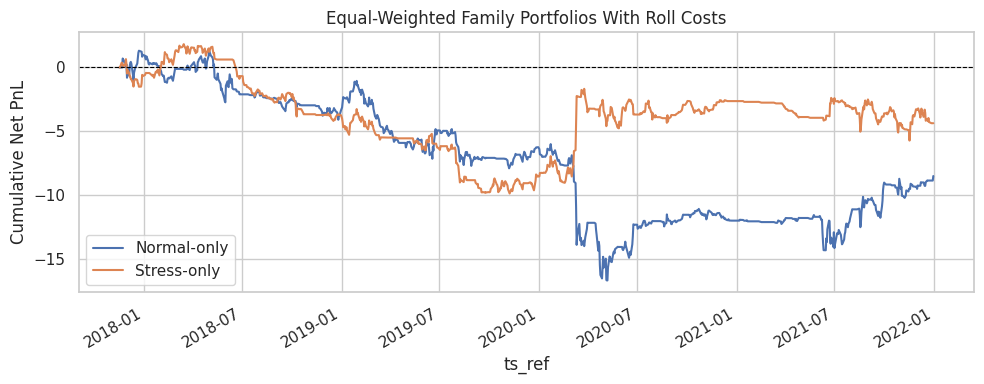

In [20]:
family_results = {}
for family_name, signal_names in [('Normal-only', NORMAL_SIGNALS), ('Stress-only', STRESS_SIGNALS)]:
    signal_panel, realised_change_panel = build_family_signal_panel(signal_names, research_frames, HORIZON_DAYS)
    family_pnl, family_positions = compute_family_pnl_with_roll(
        signal_panel,
        realised_change_panel,
        spread_roll_flags=spread_roll_flags,
        one_way_cost=ONE_WAY_COST_PER_CONTRACT,
        roll_cost=ROLL_COST_PER_CONTRACT,
        rebalance_rule=None,
    )
    pnl_clean = family_pnl.dropna()
    n_obs = len(pnl_clean)
    t_stat = (pnl_clean.mean() / pnl_clean.std(ddof=1)) * np.sqrt(n_obs) if pnl_clean.std(ddof=1) > 0 else np.nan
    family_results[family_name] = {
        'pnl': family_pnl,
        'positions': family_positions,
        'sharpe': compute_sharpe_raw(family_pnl, periods_per_year=PERIODS_PER_YEAR),
        'sortino': compute_sortino_raw(family_pnl, periods_per_year=PERIODS_PER_YEAR),
        'hit_rate': float((family_pnl > 0).mean()),
        'max_drawdown': compute_drawdown_stats(family_pnl)['max_drawdown'],
        'sharpe_t_stat': t_stat,
        'n_obs': n_obs,
    }

family_metrics_df = pd.DataFrame({
    family_name: {
        'sharpe': result['sharpe'],
        'sortino': result['sortino'],
        'hit_rate': result['hit_rate'],
        'max_drawdown': result['max_drawdown'],
        'sharpe_t_stat': result['sharpe_t_stat'],
        'n_obs': result['n_obs'],
    }
    for family_name, result in family_results.items()
}).T.round(3)
display(family_metrics_df)

plt.figure(figsize=(10, 4))
for family_name, result in family_results.items():
    result['pnl'].cumsum().plot(label=family_name)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Equal-Weighted Family Portfolios With Roll Costs')
plt.ylabel('Cumulative Net PnL')
plt.legend()
plt.tight_layout()
plt.show()


The family baselines are negative after roll costs. Normal-only has a Sharpe of -0.441 and stress-only has a Sharpe of -0.290. Stress-only has a shallower max drawdown, -11.671 versus -17.989 for normal-only, but neither family is attractive on its own.

## 10.2 Volatility-Switching Portfolio

I now add the switching overlay. The rule is intentionally simple:

1. If the crack is in a high-volatility regime, activate the two stress signals.
2. Otherwise, activate the two normal signals.

The regime is dependent on the crack's own volatility and does not depend on crude spreads or other products.

Positions update as the active regime and signal signs change.

,sharpe,sortino,hit_rate,max_drawdown,sharpe_t_stat,n_obs
Vol-switching,-0.052,-0.082,0.329,-10.468,-0.103,989.0


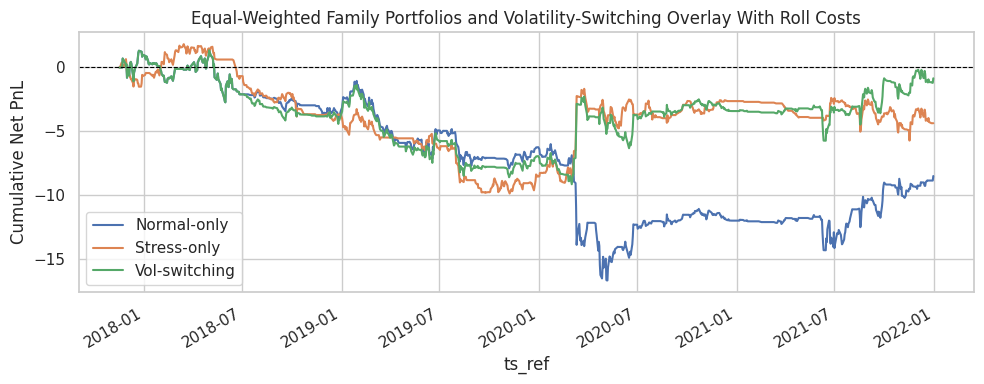

In [21]:
switching_pnl, switching_positions = compute_switching_family_pnl_with_roll(
    research_frames,
    signal_order=SIGNAL_ORDER,
    stress_signals=STRESS_SIGNALS,
    normal_signals=NORMAL_SIGNALS,
    horizon_days=HORIZON_DAYS,
    spread_roll_flags=spread_roll_flags,
    one_way_cost=ONE_WAY_COST_PER_CONTRACT,
    roll_cost=ROLL_COST_PER_CONTRACT,
    rebalance_rule=None,
)

switching_pnl_clean = switching_pnl.dropna()
switching_n_obs = len(switching_pnl_clean)
switching_t_stat = (
    (switching_pnl_clean.mean() / switching_pnl_clean.std(ddof=1)) * np.sqrt(switching_n_obs)
    if switching_pnl_clean.std(ddof=1) > 0 else np.nan
)

switching_metrics = pd.DataFrame({
    'Vol-switching': {
        'sharpe': compute_sharpe_raw(switching_pnl, periods_per_year=PERIODS_PER_YEAR),
        'sortino': compute_sortino_raw(switching_pnl, periods_per_year=PERIODS_PER_YEAR),
        'hit_rate': float((switching_pnl > 0).mean()),
        'max_drawdown': compute_drawdown_stats(switching_pnl)['max_drawdown'],
        'sharpe_t_stat': switching_t_stat,
        'n_obs': switching_n_obs,
    }
}).T.round(3)
display(switching_metrics)

plt.figure(figsize=(10, 4))
family_results['Normal-only']['pnl'].cumsum().plot(label='Normal-only')
family_results['Stress-only']['pnl'].cumsum().plot(label='Stress-only')
switching_pnl.cumsum().plot(label='Vol-switching')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Equal-Weighted Family Portfolios and Volatility-Switching Overlay With Roll Costs')
plt.ylabel('Cumulative Net PnL')
plt.legend()
plt.tight_layout()
plt.show()


The switching overlay improves the IS portfolio relative to the two family baselines -- it is marginally better than stress-only signal by the end of the backtest. Similar to the other portfolios, the vol-switching ended with negative pnl post-cost, with a Sharpe of -0.052. Its max drawdown is -10.468, which is shallower than the normal-only portfolio and slightly better than stress-only.

In [22]:
# example_spread = 'crack_321'
# vol_regime_series = research_frames[example_spread]['is_stress_regime'].astype(int)

# fig, axes = plt.subplots(nrows=2, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# axes[0].fill_between(
#     vol_regime_series.index, 0, vol_regime_series,
#     alpha=0.4, color='tab:red', label='High-vol (stress)',
# )
# axes[0].fill_between(
#     vol_regime_series.index, 0, 1 - vol_regime_series,
#     alpha=0.12, color='tab:blue', label='Low/normal vol',
# )
# axes[0].set_yticks([0, 1])
# axes[0].set_yticklabels(['Normal', 'Stress'])
# axes[0].set_title(f'Volatility Regime State ({example_spread.replace("_", " ").title()})')
# axes[0].legend(fontsize=8, loc='upper left')

# switching_pnl.cumsum().plot(ax=axes[1], label='Vol-switching', color='black', linewidth=1.5)
# family_results['Normal-only']['pnl'].cumsum().plot(ax=axes[1], label='Normal-only', linestyle='--', alpha=0.7)
# family_results['Stress-only']['pnl'].cumsum().plot(ax=axes[1], label='Stress-only', linestyle='--', alpha=0.7)
# axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
# axes[1].set_title('Cumulative Net PnL - Switching vs Family Benchmarks')
# axes[1].set_ylabel('$ PnL')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

In [23]:
sig_rows = []
for spread_name, frame in research_frames.items():
    for signal_name in SIGNAL_ORDER:
        pnl = standalone_pnl[(spread_name, signal_name)].dropna()
        n = len(pnl)
        sr = compute_sharpe_raw(pnl, periods_per_year=PERIODS_PER_YEAR)
        t_stat = (pnl.mean() / pnl.std(ddof=1)) * np.sqrt(n) if pnl.std(ddof=1) > 0 else np.nan
        sig_rows.append({
            'spread': spread_name,
            'signal': signal_label(signal_name),
            'sharpe': sr,
            'n_years': round(n / PERIODS_PER_YEAR, 1),
            'sharpe_t_stat': t_stat,
        })

sharpe_sig_df = pd.DataFrame(sig_rows).set_index(['spread', 'signal']).round(3)
display(sharpe_sig_df)

COST_LEVELS = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10]
cost_rows = []
for spread_name, frame in research_frames.items():
    for signal_name in SIGNAL_ORDER:
        row = {'spread': spread_name, 'signal': signal_label(signal_name)}
        for cost in COST_LEVELS:
            pnl_at_cost = compute_position_pnl_with_roll(
                frame[signal_name],
                frame[f'terminal_change_{HORIZON_DAYS}d'],
                spread_roll_flags[spread_name],
                one_way_cost=cost,
                roll_cost=2 * cost,
            )
            row[f'${cost:.2f}'] = round(
                compute_sharpe_raw(pnl_at_cost, periods_per_year=PERIODS_PER_YEAR), 2
            )
        cost_rows.append(row)

cost_df = pd.DataFrame(cost_rows).set_index(['spread', 'signal'])
print('\nSharpe by one-way cost assumption, with roll cost set to twice the one-way cost:')
display(cost_df)


sharpe  n_years  sharpe_t_stat
spread    signal                                               
rb_crack  Stress trend           -0.711      3.9         -1.408
          Stress mean reversion   1.075      3.9          2.131
          Normal trend           -0.380      3.9         -0.752
          Normal mean reversion  -0.291      3.9         -0.577
ho_crack  Stress trend           -0.500      3.9         -0.991
          Stress mean reversion  -0.687      3.9         -1.361
          Normal trend           -0.404      3.9         -0.800
          Normal mean reversion  -0.133      3.9         -0.264
crack_321 Stress trend           -0.377      3.9         -0.748
          Stress mean reversion   0.382      3.9          0.756
          Normal trend           -0.343      3.9         -0.679
          Normal mean reversion   0.295      3.9          0.584


Sharpe by one-way cost assumption, with roll cost set to twice the one-way cost:


$0.01  $0.02  $0.03  $0.05  $0.08  $0.10
spread    signal                                                         
rb_crack  Stress trend           -0.59  -0.65  -0.71  -0.83  -1.01  -1.12
          Stress mean reversion   1.17   1.12   1.08   0.98   0.84   0.74
          Normal trend           -0.31  -0.35  -0.38  -0.45  -0.55  -0.62
          Normal mean reversion  -0.17  -0.23  -0.29  -0.42  -0.61  -0.73
ho_crack  Stress trend           -0.36  -0.43  -0.50  -0.64  -0.84  -0.97
          Stress mean reversion  -0.59  -0.64  -0.69  -0.78  -0.92  -1.01
          Normal trend           -0.30  -0.35  -0.40  -0.51  -0.66  -0.76
          Normal mean reversion  -0.01  -0.07  -0.13  -0.25  -0.43  -0.55
crack_321 Stress trend           -0.23  -0.30  -0.38  -0.53  -0.75  -0.89
          Stress mean reversion   0.51   0.44   0.38   0.26   0.07  -0.05
          Normal trend           -0.24  -0.29  -0.34  -0.44  -0.59  -0.68
          Normal mean reversion   0.45   0.37   0.29   0.14  -0.10  -0.26

## 10.3 Signal-Strength and Threshold Sizing

I now test an alternative execution model with two changes:

1. Trend signals use clipped volatility-scaled magnitude:

$$
\text{position}^{trend}_t = \frac{\text{clip}(S^{trend}_t, -3, 3)}{3}
$$

2. Mean-reversion signals use percentile-rank distance from neutral:

$$
\text{position}^{mr}_t = -2 \times (Rank_t(L) - 0.5)
$$

I also add a simple threshold version where positions only updates when the target position changes by at least 0.10. Roll costs are applied to any active residual position (proportionately) on roll dates, so lower turnover does not eliminate the monthly roll drag, but a lower cost is applied when the positions are sized less than 1.

family  sharpe_sign  sharpe_scaled  \
spread    signal                                                              
rb_crack  Stress trend                    trend       -0.711         -1.168   
          Stress mean reversion  mean_reversion        1.075          0.170   
          Normal trend                    trend       -0.380         -0.538   
          Normal mean reversion  mean_reversion       -0.291          0.001   
ho_crack  Stress trend                    trend       -0.500         -0.556   
          Stress mean reversion  mean_reversion       -0.687         -0.411   
          Normal trend                    trend       -0.404         -0.328   
          Normal mean reversion  mean_reversion       -0.133         -0.571   
crack_321 Stress trend                    trend       -0.377         -0.544   
          Stress mean reversion  mean_reversion        0.382          0.377   
          Normal trend                    trend       -0.343         -0.326   
          Normal mean reversion  mean_reversion        0.295          0.353   

                                 turnover_sign  turnover_scaled  sharpe_delta  \
spread    signal                                                                
rb_crack  Stress trend                   0.171            0.161        -0.457   
          Stress mean reversion          0.114            0.084        -0.905   
          Normal trend                   0.054            0.048        -0.158   
          Normal mean reversion          0.187            0.176         0.292   
ho_crack  Stress trend                   0.151            0.132        -0.056   
          Stress mean reversion          0.074            0.097         0.276   
          Normal trend                   0.090            0.093         0.076   
          Normal mean reversion          0.116            0.176        -0.438   
crack_321 Stress trend                   0.179            0.160        -0.167   
          Stress mean reversion          0.130            0.097        -0.005   
          Normal trend                   0.086            0.093         0.017   
          Normal mean reversion          0.195            0.179         0.058   

                                 turnover_delta  
spread    signal                                 
rb_crack  Stress trend                   -0.010  
          Stress mean reversion          -0.030  
          Normal trend                   -0.006  
          Normal mean reversion          -0.011  
ho_crack  Stress trend                   -0.019  
          Stress mean reversion           0.023  
          Normal trend                    0.003  
          Normal mean reversion           0.060  
crack_321 Stress trend                   -0.019  
          Stress mean reversion          -0.033  
          Normal trend                    0.007  
          Normal mean reversion          -0.016

,sharpe,max_drawdown,sharpe_t_stat
Sign benchmark,-0.052,-10.468,-0.103
Scaled daily,-0.692,-12.124,-1.370
Scaled threshold,-0.372,-8.564,-0.737


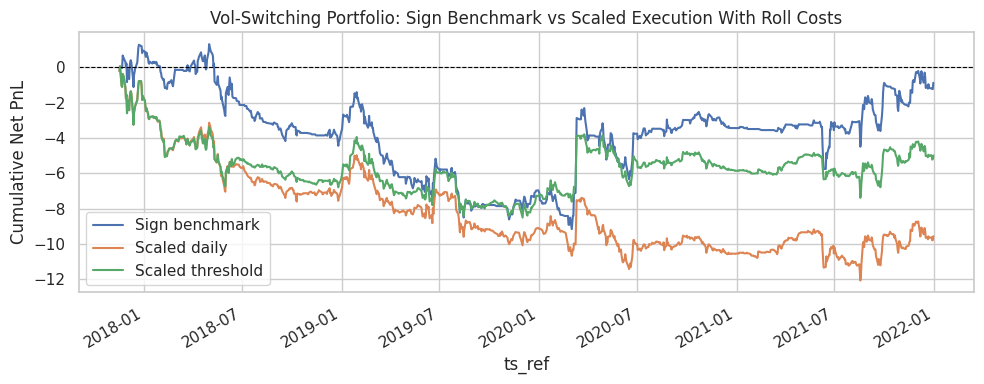

In [24]:
SCALING_CLIP_Z = 3.0
RANK_DEADBAND = 0.20
POSITION_CHANGE_THRESHOLD = 0.10


# Standalone: sign-based benchmark versus rank/trend-aware scaled positions.
scaled_rows = []
for spread_name, frame in research_frames.items():
    target_panel = build_signal_target_position_panel(
        frame,
        signal_configs=SIGNAL_CONFIGS,
        signal_order=SIGNAL_ORDER,
        sizing_method='signal_scaled',
        clip_value=SCALING_CLIP_Z,
        rank_deadband=RANK_DEADBAND,
    )

    for signal_name in SIGNAL_ORDER:
        pnl_sign = standalone_pnl[(spread_name, signal_name)].dropna()
        pnl_scaled = compute_position_pnl_from_target_with_roll(
            target_panel[signal_name],
            frame[f'terminal_change_{HORIZON_DAYS}d'],
            spread_roll_flags[spread_name],
            one_way_cost=ONE_WAY_COST_PER_CONTRACT,
            roll_cost=ROLL_COST_PER_CONTRACT,
        ).dropna()
        scaled_rows.append({
            'spread': spread_name,
            'signal': signal_label(signal_name),
            'family': SIGNAL_CONFIGS[signal_name]['family'],
            'sharpe_sign': compute_sharpe_raw(pnl_sign, periods_per_year=PERIODS_PER_YEAR),
            'sharpe_scaled': compute_sharpe_raw(pnl_scaled, periods_per_year=PERIODS_PER_YEAR),
            'turnover_sign': compute_position_turnover(frame[signal_name]),
            'turnover_scaled': target_panel[signal_name].fillna(0.0).diff().abs().fillna(target_panel[signal_name].abs()).mean(),
        })

scaled_comparison_df = pd.DataFrame(scaled_rows).set_index(['spread', 'signal']).round(3)
scaled_comparison_df['sharpe_delta'] = (scaled_comparison_df['sharpe_scaled'] - scaled_comparison_df['sharpe_sign']).round(3)
scaled_comparison_df['turnover_delta'] = (scaled_comparison_df['turnover_scaled'] - scaled_comparison_df['turnover_sign']).round(3)
display(scaled_comparison_df)


# Vol-switching portfolio with daily scaled targets and threshold-updated scaled targets.
scaled_target_panel, scaled_change_panel = build_switching_target_and_change_panels(
    research_frames,
    sizing_method='signal_scaled',
    signal_configs=SIGNAL_CONFIGS,
    signal_order=SIGNAL_ORDER,
    stress_signals=STRESS_SIGNALS,
    horizon_days=HORIZON_DAYS,
    clip_value=SCALING_CLIP_Z,
    rank_deadband=RANK_DEADBAND,
)

scaled_switching_pnl, scaled_positions = compute_portfolio_pnl_from_target_positions_with_roll(
    scaled_target_panel,
    scaled_change_panel,
    spread_roll_flags=spread_roll_flags,
    one_way_cost=ONE_WAY_COST_PER_CONTRACT,
    roll_cost=ROLL_COST_PER_CONTRACT,
    rebalance_rule=None,
    position_change_threshold=None,
    normalise_by_active_count=True,
    pnl_name='scaled_switching_roll_aware_net_pnl',
)

threshold_switching_pnl, threshold_positions = compute_portfolio_pnl_from_target_positions_with_roll(
    scaled_target_panel,
    scaled_change_panel,
    spread_roll_flags=spread_roll_flags,
    one_way_cost=ONE_WAY_COST_PER_CONTRACT,
    roll_cost=ROLL_COST_PER_CONTRACT,
    rebalance_rule=None,
    position_change_threshold=POSITION_CHANGE_THRESHOLD,
    normalise_by_active_count=True,
    pnl_name='threshold_scaled_switching_roll_aware_net_pnl',
)


sizing_comparison = pd.DataFrame({
    'Sign benchmark': {
        'sharpe': compute_sharpe_raw(switching_pnl, periods_per_year=PERIODS_PER_YEAR),
        'max_drawdown': compute_drawdown_stats(switching_pnl)['max_drawdown'],
        'sharpe_t_stat': switching_t_stat,
    },
    'Scaled daily': {
        'sharpe': compute_sharpe_raw(scaled_switching_pnl, periods_per_year=PERIODS_PER_YEAR),
        'max_drawdown': compute_drawdown_stats(scaled_switching_pnl)['max_drawdown'],
        'sharpe_t_stat': compute_pnl_t_stat(scaled_switching_pnl),
    },
    'Scaled threshold': {
        'sharpe': compute_sharpe_raw(threshold_switching_pnl, periods_per_year=PERIODS_PER_YEAR),
        'max_drawdown': compute_drawdown_stats(threshold_switching_pnl)['max_drawdown'],
        'sharpe_t_stat': compute_pnl_t_stat(threshold_switching_pnl),
    },
}).T.round(3)
display(sizing_comparison)

plt.figure(figsize=(10, 4))
switching_pnl.cumsum().plot(label='Sign benchmark')
scaled_switching_pnl.cumsum().plot(label='Scaled daily')
threshold_switching_pnl.cumsum().plot(label='Scaled threshold')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Vol-Switching Portfolio: Sign Benchmark vs Scaled Execution With Roll Costs')
plt.ylabel('Cumulative Net PnL')
plt.legend()
plt.tight_layout()
plt.show()


The sizing rules do not improve the benchmark in this run. The sign-based switching portfolio has a Sharpe of -0.052 after roll costs while the scaled daily version falls to -0.692 and the threshold-scaled version has a negative Sharpe of -0.372.

This is slightly unexpected as I would have expected the daily scaled position to avoid periods where signals are weak, i.e. expected returns are low, or volatility is too high. The poor performance of the daily scaled version may therefore be partly due to higher turnover and cost drag overwhelming whatever benefit the scaling rule provides.

---

# 11. Out-of-Sample Validation

Let's now proceed to perform a short study on the out-of-sample data (from 2022-01-01 to 2026-02-17). The parameters are fixed upfront and not re-estimated.

The OOS period includes several unusual shocks in the market, such as the 2022 Russia-Ukraine war, 2025 Trump inauguration, etc. It is not a quiet period and for signal research that survived up to this point, this could be a useful stress test.

In [25]:
signal_oos_rows = []
for period_label, frames in [('IS', backtest_frames_is), ('OOS', backtest_frames_oos)]:
    for spread_name, frame in frames.items():
        for signal_name in SIGNAL_ORDER:
            tc = frame[f'terminal_change_{HORIZON_DAYS}d']
            stats = compute_predictive_corr_stats(frame[signal_name], tc, method='spearman')
            pnl = compute_position_pnl_with_roll(
                frame[signal_name],
                tc,
                spread_roll_flags[spread_name],
                one_way_cost=ONE_WAY_COST_PER_CONTRACT,
                roll_cost=ROLL_COST_PER_CONTRACT,
            ).dropna()
            n = len(pnl)
            t_stat = (
                pnl.mean() / pnl.std(ddof=1) * np.sqrt(n)
                if n > 1 and pnl.std(ddof=1) > 0 else np.nan
            )
            signal_oos_rows.append({
                'period': period_label,
                'spread': spread_name,
                'signal': signal_label(signal_name),
                'ic': stats['corr'],
                'ic_t_stat': stats['t_stat'],
                'sharpe': compute_sharpe_raw(pnl, periods_per_year=PERIODS_PER_YEAR),
                'sharpe_t_stat': t_stat,
                'n_obs': stats['n_obs'],
            })

signal_oos_df = pd.DataFrame(signal_oos_rows)
signal_oos_pivot = signal_oos_df.pivot_table(
    index=['spread', 'signal'],
    columns='period',
    values=['ic', 'ic_t_stat', 'sharpe', 'sharpe_t_stat'],
)
signal_oos_pivot.columns = [f'{metric}_{period}' for metric, period in signal_oos_pivot.columns]
signal_oos_pivot = signal_oos_pivot[
    ['ic_IS', 'ic_t_stat_IS', 'ic_OOS', 'ic_t_stat_OOS',
     'sharpe_IS', 'sharpe_t_stat_IS', 'sharpe_OOS', 'sharpe_t_stat_OOS']
]
display(signal_oos_pivot.round(3))


ic_IS  ic_t_stat_IS  ic_OOS  ic_t_stat_OOS  \
spread    signal                                                              
crack_321 Normal mean reversion  0.064         2.138  -0.011         -0.356   
          Normal trend          -0.028        -0.920   0.009          0.263   
          Stress mean reversion  0.057         1.794   0.006          0.179   
          Stress trend          -0.036        -1.142   0.028          0.856   
ho_crack  Normal mean reversion -0.006        -0.197   0.005          0.159   
          Normal trend          -0.030        -0.959   0.003          0.079   
          Stress mean reversion -0.015        -0.465  -0.008         -0.247   
          Stress trend          -0.018        -0.605   0.006          0.170   
rb_crack  Normal mean reversion  0.038         1.251  -0.018         -0.596   
          Normal trend          -0.025        -0.840   0.009          0.311   
          Stress mean reversion  0.032         0.961  -0.027         -0.875   
          Stress trend          -0.046        -1.464  -0.002         -0.061   

                                 sharpe_IS  sharpe_t_stat_IS  sharpe_OOS  \
spread    signal                                                           
crack_321 Normal mean reversion      0.295             0.584      -0.247   
          Normal trend              -0.343            -0.679       0.332   
          Stress mean reversion      0.382             0.756       0.265   
          Stress trend              -0.377            -0.748       0.259   
ho_crack  Normal mean reversion     -0.133            -0.264      -0.042   
          Normal trend              -0.404            -0.800       0.464   
          Stress mean reversion     -0.687            -1.361      -0.435   
          Stress trend              -0.500            -0.991       0.062   
rb_crack  Normal mean reversion     -0.291            -0.577      -0.387   
          Normal trend              -0.380            -0.752       0.474   
          Stress mean reversion      1.075             2.131      -0.224   
          Stress trend              -0.711            -1.408       0.220   

                                 sharpe_t_stat_OOS  
spread    signal                                    
crack_321 Normal mean reversion             -0.484  
          Normal trend                       0.652  
          Stress mean reversion              0.521  
          Stress trend                       0.509  
ho_crack  Normal mean reversion             -0.083  
          Normal trend                       0.912  
          Stress mean reversion             -0.855  
          Stress trend                       0.121  
rb_crack  Normal mean reversion             -0.762  
          Normal trend                       0.932  
          Stress mean reversion             -0.440  
          Stress trend                       0.434

,sharpe,sharpe_t_stat,max_drawdown,n_obs
period,,,,
IS,-0.052,-0.103,-10.468,989
OOS,0.313,0.615,-14.688,975


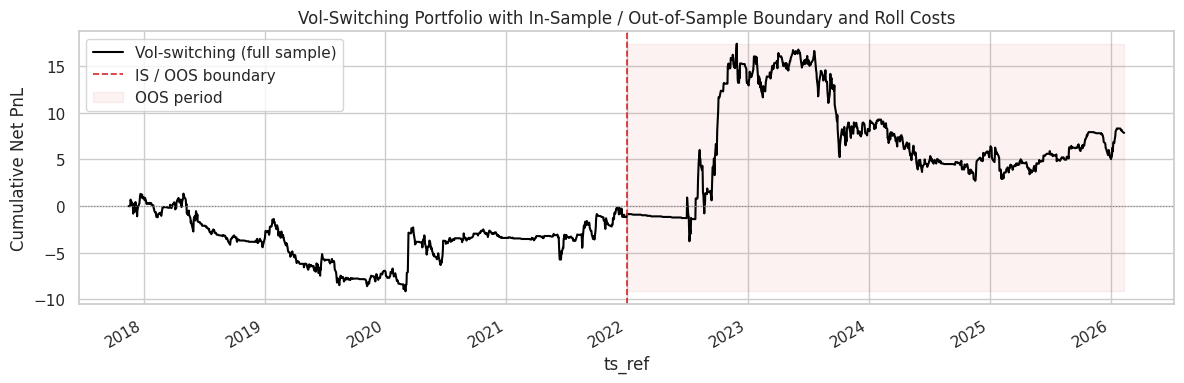

In [26]:
# Portfolio-level IS vs OOS: vol-switching portfolio
portfolio_oos_rows = []
for period_label, frames in [('IS', backtest_frames_is), ('OOS', backtest_frames_oos)]:
    sw_pnl, _ = compute_switching_family_pnl_with_roll(
        frames,
        signal_order=SIGNAL_ORDER,
        stress_signals=STRESS_SIGNALS,
        normal_signals=NORMAL_SIGNALS,
        horizon_days=HORIZON_DAYS,
        spread_roll_flags=spread_roll_flags,
        one_way_cost=ONE_WAY_COST_PER_CONTRACT,
        roll_cost=ROLL_COST_PER_CONTRACT,
        rebalance_rule=None,
    )
    pnl_clean = sw_pnl.dropna()
    n = len(pnl_clean)
    t_stat = (pnl_clean.mean() / pnl_clean.std(ddof=1)) * np.sqrt(n) if (n > 1 and pnl_clean.std(ddof=1) > 0) else np.nan
    portfolio_oos_rows.append({
        'period': period_label,
        'sharpe': compute_sharpe_raw(sw_pnl, periods_per_year=PERIODS_PER_YEAR),
        'sharpe_t_stat': t_stat,
        'max_drawdown': compute_drawdown_stats(sw_pnl)['max_drawdown'],
        'n_obs': n,
        'pnl': sw_pnl,
    })

portfolio_oos_summary = pd.DataFrame([
    {k: v for k, v in row.items() if k != 'pnl'}
    for row in portfolio_oos_rows
]).set_index('period').round(3)
display(portfolio_oos_summary)

switching_pnl_full, switching_positions_full = compute_switching_family_pnl_with_roll(
    backtest_frames,
    signal_order=SIGNAL_ORDER,
    stress_signals=STRESS_SIGNALS,
    normal_signals=NORMAL_SIGNALS,
    horizon_days=HORIZON_DAYS,
    spread_roll_flags=spread_roll_flags,
    one_way_cost=ONE_WAY_COST_PER_CONTRACT,
    roll_cost=ROLL_COST_PER_CONTRACT,
    rebalance_rule=None,
)

fig, ax = plt.subplots(figsize=(12, 4))
switching_pnl_full.cumsum().plot(ax=ax, label='Vol-switching (full sample)', color='black', linewidth=1.5)
ax.axvline(OOS_START, color='tab:red', linestyle='--', linewidth=1.2, label='IS / OOS boundary')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.fill_betweenx(
    [switching_pnl_full.cumsum().min(), switching_pnl_full.cumsum().max()],
    OOS_START, switching_pnl_full.index[-1],
    alpha=0.06, color='tab:red', label='OOS period',
)
ax.set_title('Vol-Switching Portfolio with In-Sample / Out-of-Sample Boundary and Roll Costs')
ax.set_ylabel('Cumulative Net PnL')
ax.legend()
plt.tight_layout()
plt.show()


The signal-level OOS table remains mixed, consistent with earlier IS analysis.

At the portfolio level, the vol-switching strategy improves from an IS Sharpe of -0.052 to an OOS Sharpe of 0.313 after roll costs. That is better out of sample than in sample, but the OOS t-stat is only 0.615 and the max drawdown is larger at -14.688. A large part of positive pnl comes from the 2022 Russian-Ukraine war. For the remaining periods beyond that, the pnl has largely been moving sideways.

The evidence here is that these signals are insufficient to be treated as standalone trading strategies.

# 12. Areas of Improvement

- Lack of physical-market information. We could pull in EIA weekly status report data from DOE to better inform our research. Current regimes are price derived and may not properly encapsulate regional fundamentals.

- The OOS result is also event-sensitive. The positive OOS portfolio result is helped by the 2022 energy shock.

- Period of study includes multiple unusual periods, such as COVID, Russia-Ukraine war, etc